In [ ]:
from trastuzumab.pinns import Pinn, get_spatial_antibody_distribution
from pathlib import Path
models_dir = Path.cwd().parent/'models'
pinn = Pinn.load(models_dir/'benchmark_pinn.pt')
get_spatial_antibody_distribution(1.0, pinn, 1.0)

In [ ]:
import torch
from trastuzumab.pinns import Pinn, get_spatial_antibody_distribution

# // hyperparameters.
_L = 1060 / 1060
_T = 1.0 / 24 
# //
DEVICE = 'cpu'
# //
NUM_COLLOC = 4000
NUM_INITIAL = 300
NUM_CENTER = 300
NUM_SURFACE = 300
# //
ADAM_EPOCHS = 10000
LBFGS_EPOCHS = 2000
# //
benchmark_pinn = Pinn(NUM_COLLOC, NUM_INITIAL, NUM_CENTER, NUM_SURFACE, layers=3, neurons=64, device=DEVICE, u_bounds=[1, _T])

optimizer = torch.optim.Adam(params=benchmark_pinn.net.parameters(), lr=0.001)
benchmark_pinn.train_adam(epochs=10000, optimizer=optimizer, L=_L)
get_spatial_antibody_distribution(t_exp = _T, pinn=benchmark_pinn, L=_L)

In [ ]:
benchmark_pinn.train_adam(epochs=10000, optimizer=optimizer, L=_L)
get_spatial_antibody_distribution(t_exp = _T, pinn=benchmark_pinn, L=_L)

In [ ]:
from pathlib import Path
models_path = Path.cwd().parent/'models'
benchmark_pinn.save(models_path/'benchmark_pinn.pt')

In [ ]:
def greedy_training(from_t, to_t, step, pinn: Pinn, _L):
    for ti in range(from_t, to_t, step):
        NEW_T = ti/24
        NUM_COLLOC = 4000 + int(NEW_T*24) * 200
        NUM_INITIAL = 300 + int(NEW_T*24) * 20
        NUM_CENTER = 300 + int(NEW_T*24) * 20
        NUM_SURFACE = 300 + int(NEW_T*24) * 20
        pinn.resample_datasets(NUM_COLLOC, NUM_INITIAL, NUM_CENTER, NUM_SURFACE, upper_bounds=[1, NEW_T])
        pinn.DATASET.plotme()
        pinn.train_adam(epochs=10000, optimizer=optimizer, L=_L)
        get_spatial_antibody_distribution(t_exp = NEW_T, pinn=pinn, L=_L)

In [ ]:
greedy_training(2, 25, 4, benchmark_pinn, 1.0)

In [ ]:
for ti in range(1, 25):
    NEW_T = ti/24
    NUM_COLLOC = 2000 + int(NEW_T*24) * 200
    NUM_INITIAL = 200 + int(NEW_T*24) * 20
    NUM_CENTER = 200 + int(NEW_T*24) * 20
    NUM_SURFACE = 200 + int(NEW_T*24) * 20

    time_marching_pinn.resample_datasets(NUM_COLLOC, NUM_INITIAL, NUM_CENTER, NUM_SURFACE, upper_bounds=[1, NEW_T])
    time_marching_pinn.DATASET.plotme()
    time_marching_pinn.train_adam(epochs=7000, optimizer=optimizer, L=0.5)
    get_spatial_antibody_distribution(t_exp = NEW_T, pinn=time_marching_pinn, L=.5)

In [ ]:
from pathlib import Path
time_marching_pinn.save(Path.cwd().parent / 'models/time_marching_v01.pt')

In [ ]:
## brute force pinn

import torch
from trastuzumab.pinns import Pinn, get_spatial_antibody_distribution
SIMULATION_HOURS = 24


# // hyperparameters.
T = SIMULATION_HOURS / 24
# //
DEVICE = 'cpu'
# //
NUM_COLLOC = 2000
NUM_INITIAL = 200
NUM_CENTER = 200
NUM_SURFACE = 200
# //
ADAM_EPOCHS = 10000
LBFGS_EPOCHS = 2000
# //
brute_force = Pinn(NUM_COLLOC, NUM_INITIAL, NUM_CENTER, NUM_SURFACE, layers=3, neurons=64, device=DEVICE, u_bounds=[1, T])
# forward_pinn.DATASET.plotme()

LAMBDA = 1060 / 1060
optimizer = torch.optim.Adam(brute_force.net.parameters(), 0.001)
brute_force.train_adam(epochs=10000, optimizer=optimizer, L=LAMBDA)
get_spatial_antibody_distribution(t_exp=24/24, pinn=brute_force, L=LAMBDA)

In [ ]:
brute_force.train_adam(epochs=10000, optimizer=optimizer, network_lr=0.001)
get_spatial_antibody_distribution(t_exp=24/24, pinn=brute_force, L=LAMBDA)

In [ ]:
get_spatial_antibody_distribution(t_exp=24/24, pinn=brute_force, L=LAMBDA)

In [ ]:
brute_force.train_adam(epochs=10000, optimizer=optimizer, network_lr=0.0001)
get_spatial_antibody_distribution(t_exp=24/24, pinn=brute_force, L=LAMBDA)

In [ ]:
from pathlib import Path

brute_force.save(Path.cwd().parent/'models/brute_force_modelv02.pt')

[uptake] solver: The solver successfully reached the end of the integration interval.
icc_pinn        global=9.081e-01  per_species={'c0': '9.21e-01', 'c1': '8.46e-01', 'c2': '8.88e-01'}
rt_scheduled_model  global=9.168e-01  per_species={'c0': '9.66e-01', 'c1': '6.98e-01', 'c2': '7.54e-01'}
time_marching_modelv01  global=8.805e-01  per_species={'c0': '9.51e-01', 'c1': '5.49e-01', 'c2': '5.93e-01'}
brute_force_modelv01  global=8.872e-01  per_species={'c0': '9.23e-01', 'c1': '7.30e-01', 'c2': '7.85e-01'}
brute_force_modelv02  global=8.986e-01  per_species={'c0': '9.26e-01', 'c1': '7.78e-01', 'c2': '8.28e-01'}


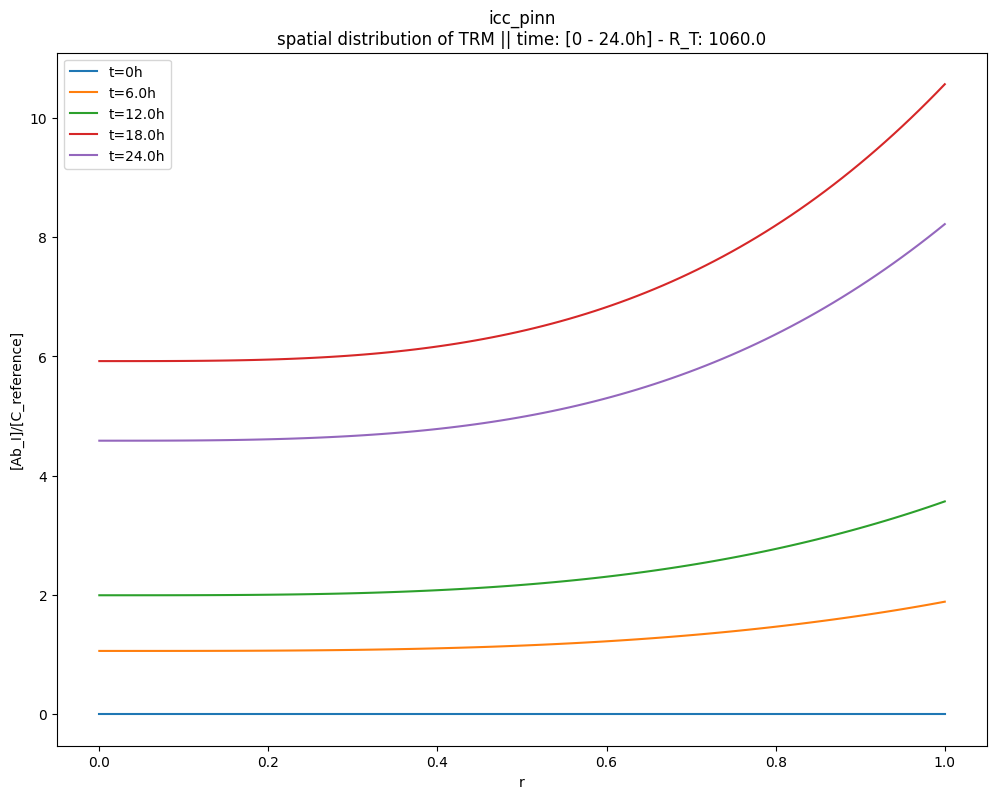

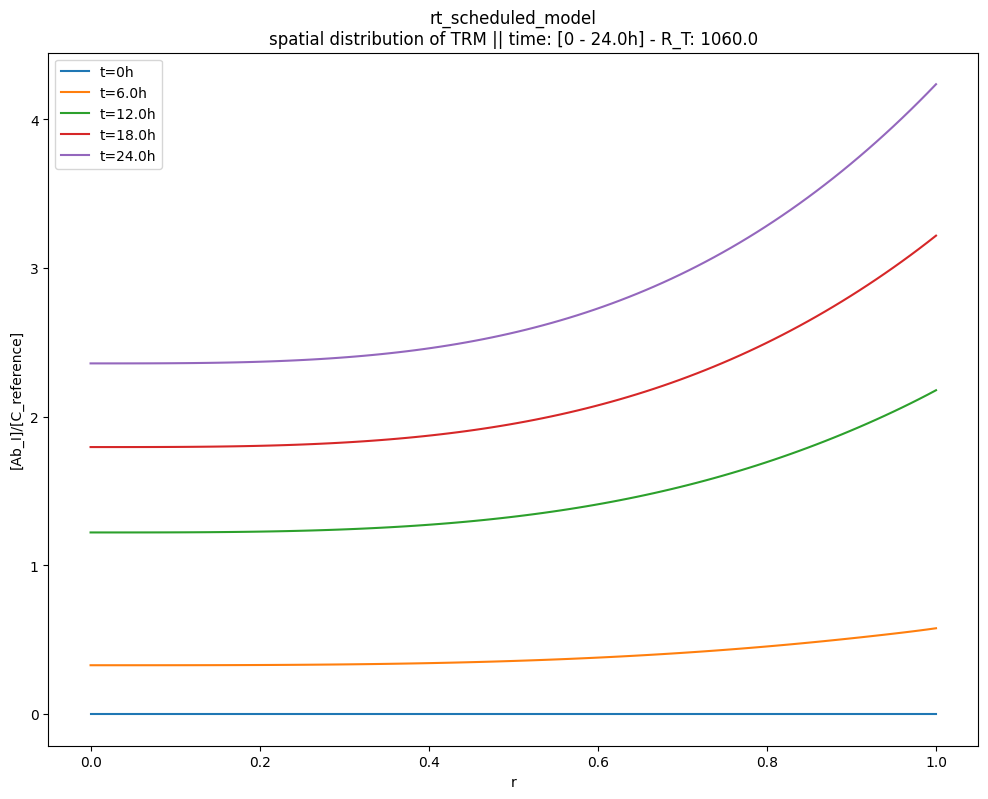

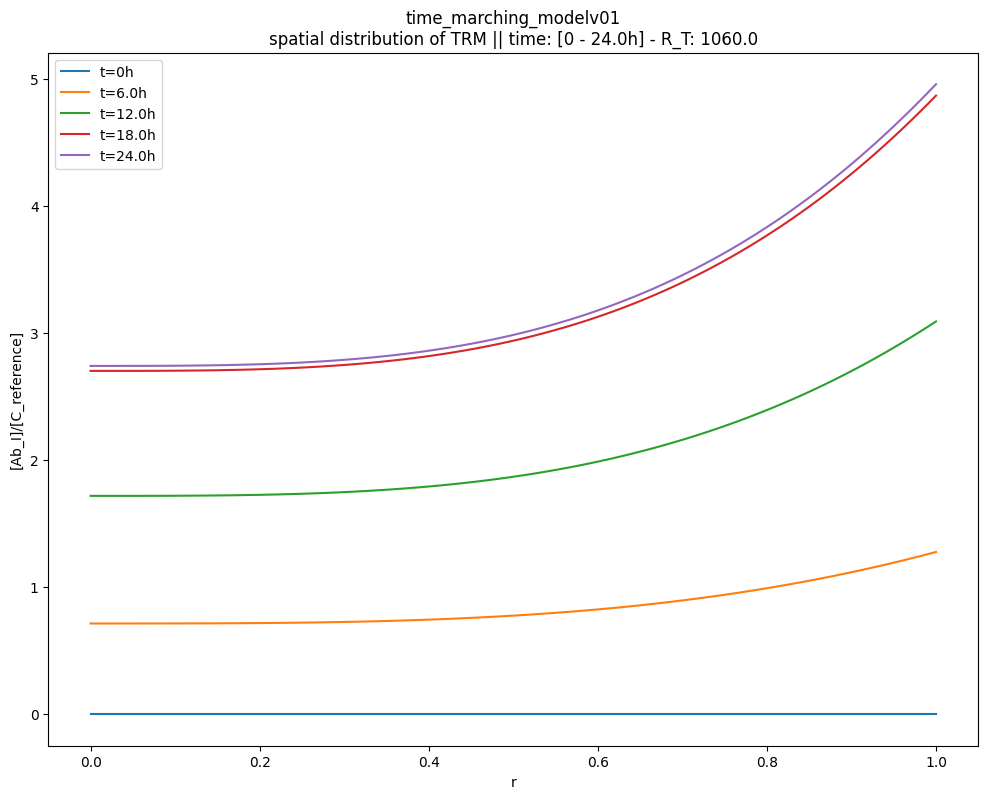

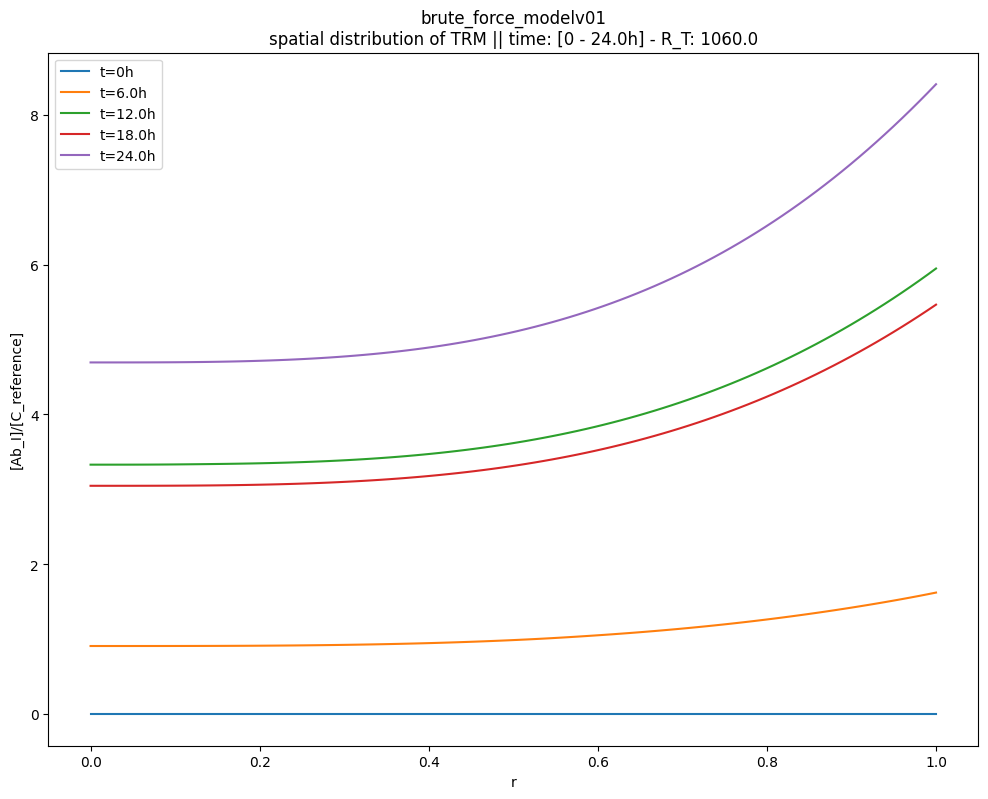

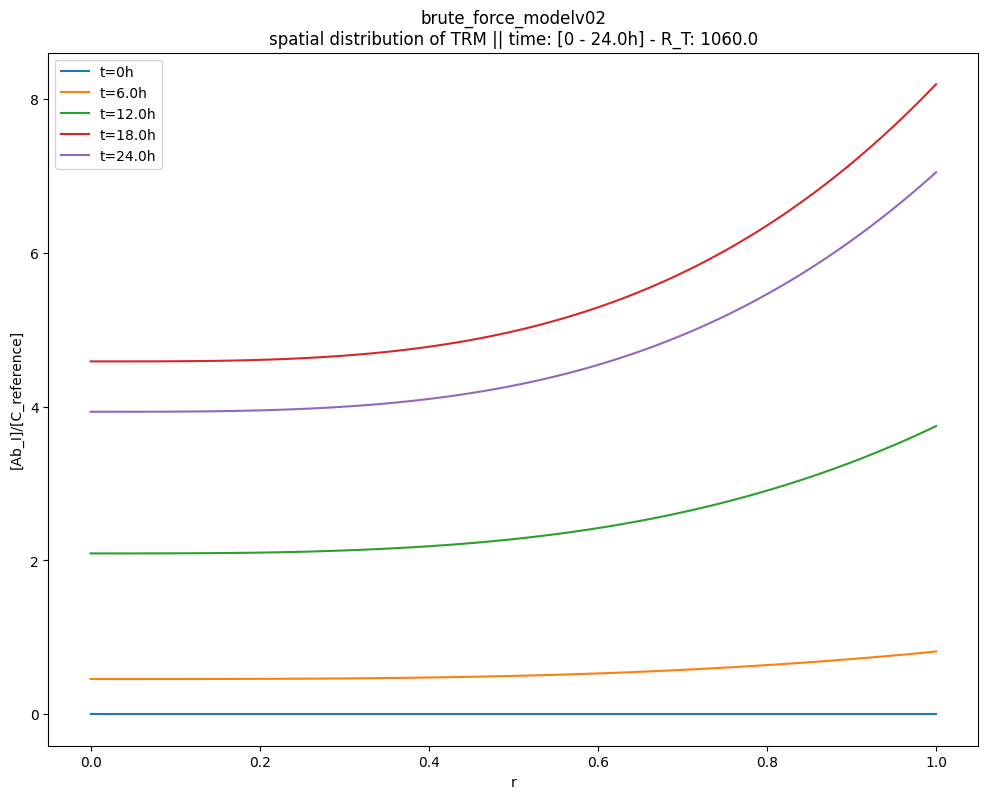

[None, None, None, None, None]

In [2]:
## save/load...

from trastuzumab import evaluation, fdm, pinns
from trastuzumab.utils import plotting as pl
import numpy as np
import pathlib

models_dir = pathlib.Path.cwd().parent/'models'


x, sol = fdm.run_fdm(m=100, phase_name='uptake', y0=np.zeros(3 * 101), t_final=1.0)
ev = evaluation.Evaluator(fdm_x=x, fdm_sol=sol.sol, n_t=101)

models = {
    'icc_pinn': pinns.ForwardPinn.load(models_dir / 'icc_pinn.pt'),
    'rt_scheduled_model': pinns.ForwardPinn.load(models_dir / 'rt_scheduled_model.pt'),
    'time_marching_modelv01': pinns.ForwardPinn.load(models_dir / 'time_marching_modelv01.pt'),
    'brute_force_modelv01': pinns.ForwardPinn.load(models_dir / 'brute_force_modelv01.pt'),
    'brute_force_modelv02': pinns.ForwardPinn.load(models_dir / 'brute_force_modelv02.pt'),
}

results = ev.compare(models)
for label, r in results.items():
    print(f"{label:14s}  global={r['global_l2']:.3e}  per_species={ {k: f'{v:.2e}' for k,v in r['per_species'].items()} }")


[pl.get_spatial_antibody_distribution(1.0, k, model, L=1.0) for k, model in models.items()]

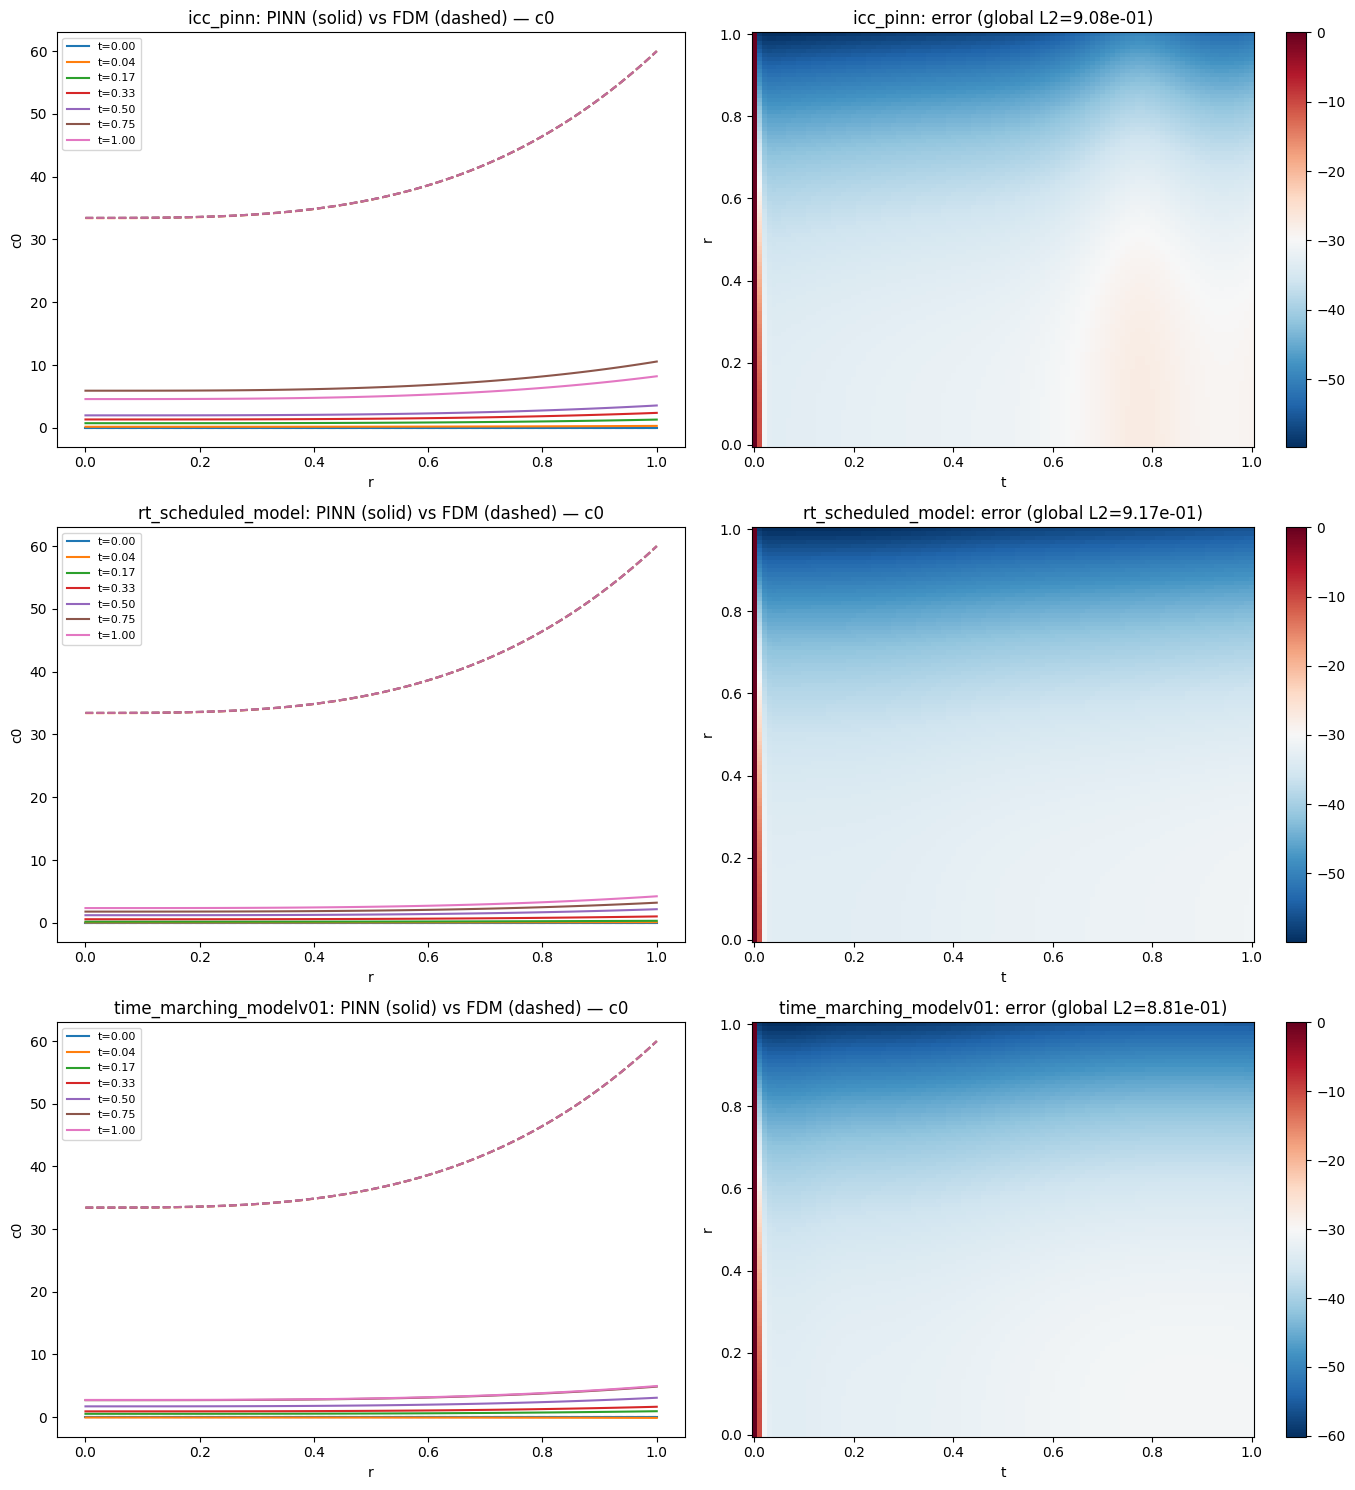

In [22]:
from trastuzumab.utils.plotting import plot_comparison
plot_comparison(results, ev, models)

In [ ]:
import torch

from trastuzumab import pinns, residuals, neural_nets, datasets, sampling

dummy_pinn = pinns.Pinn(n_col=4000, n_initial=200, n_center=200, n_surface=200, u_bounds=[1, 1], device='cpu', layers=3, neurons=64)
dummy_pinn.collocation_training_dataset.plotme()

optimizer = torch.optim.Adam(dummy_pinn.net.parameters(), 0.001)
sampler = datasets.DatasetSampler()

dummy_pinn.train_adam(optimizer=optimizer, epochs=20000)

for N in range(5):
    cand = sampler.sample_collocation_points(50000, u_bounds=[1, 1])
    scores = sampling._score(net=dummy_pinn.net, canditates=cand, L=1.0)

    selected = sampling._select(scores=scores, canditates=cand, m_add=500)
    selected.plotme()
    dummy_pinn.collocation_training_dataset += selected
    dummy_pinn.collocation_training_dataset.plotme()

    dummy_pinn.train_adam(optimizer=optimizer, epochs=10000)
    pinns.get_spatial_antibody_distribution(t_exp=1.0, pinn=dummy_pinn, L=1.0)


neural network weights initialized succesfully
neural network weights initialized succesfully


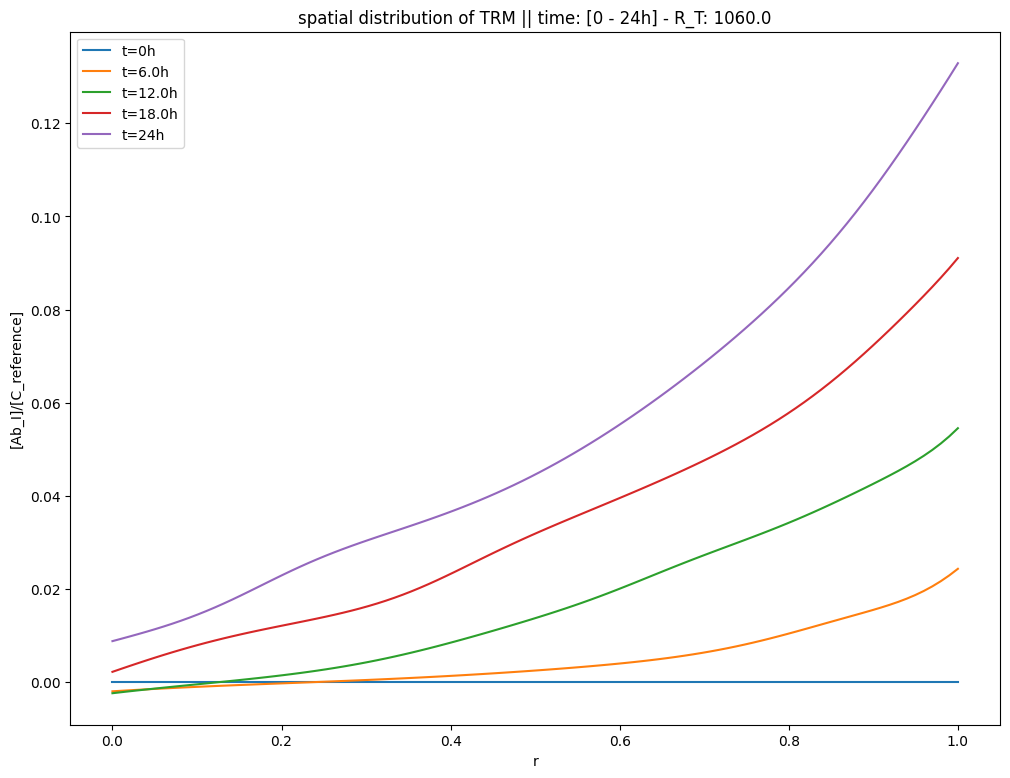

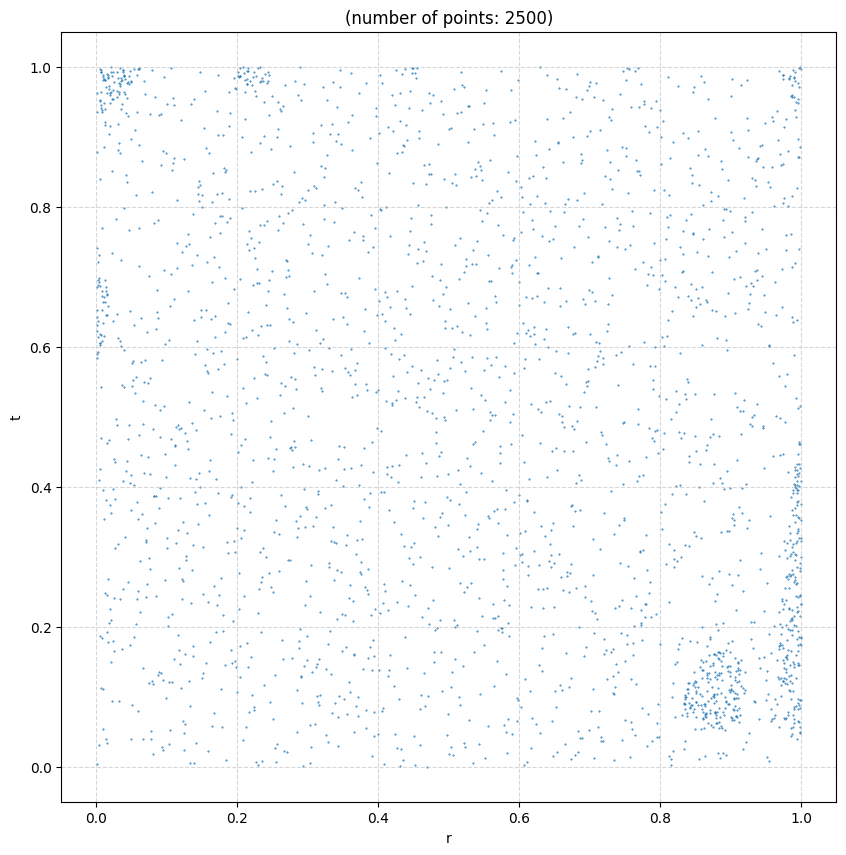

[RAR-G] round  1 | points= 2500 | max_res=1.794e+02 | mean_res=1.487e+01
Adam Training started...
- Epochs: 10000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 7.7202e+00 | 4.4776e-01 | 9.4207e-01 | 1.0471e-04 | 1.1900e-03 | 6.3290e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 7.5233e+00 | 3.2724e-01 | 7.6597e-01 | 2.2091e-04 | 1.1937e-03 | 6.4287e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 7.3272e+00 | 2.8445e-01 | 6.4289e-01 | 1.5736e-04 | 1.1450e-03 | 6.3986e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 7.1967e+00 | 2.5871e-01 | 5.7944e-01 | 1.3552e-04 | 1.1377e-0

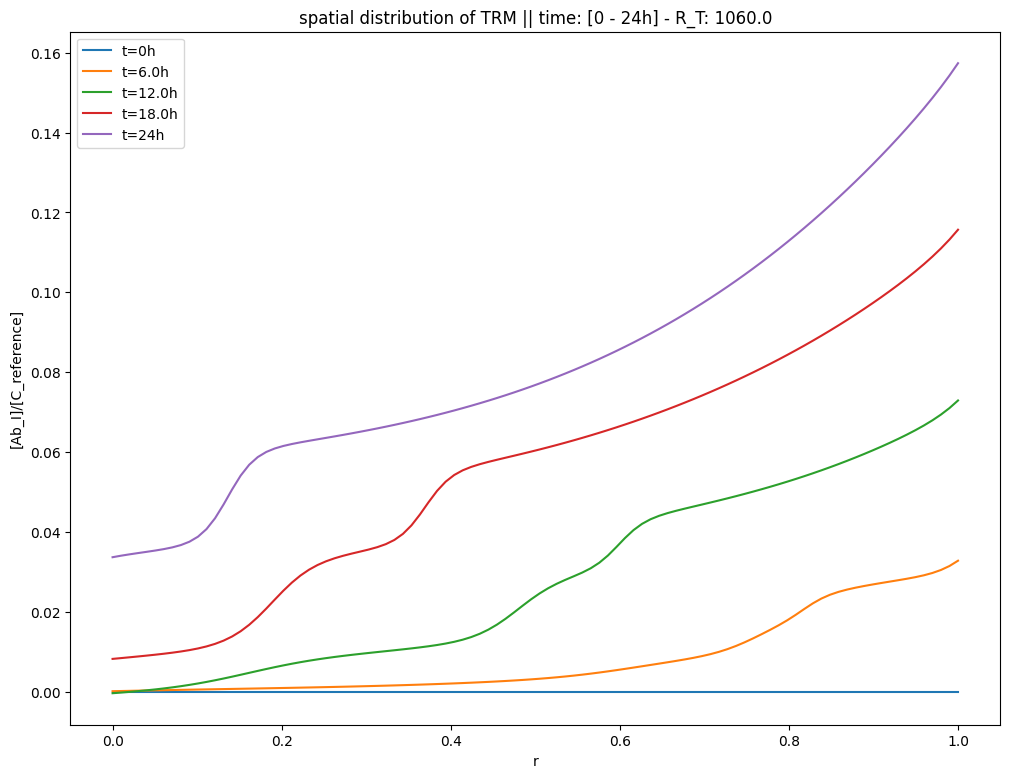

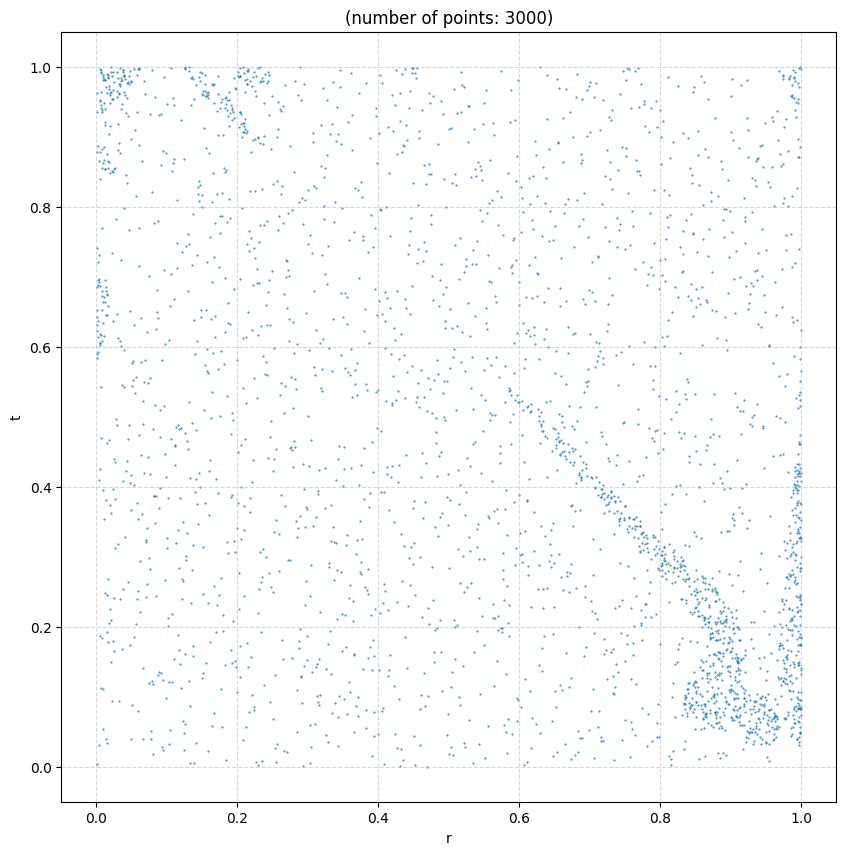

[RAR-G] round  2 | points= 3000 | max_res=9.109e+01 | mean_res=1.092e+01
Adam Training started...
- Epochs: 10000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 3.0682e+00 | 4.3487e-01 | 3.2648e-01 | 3.4473e-04 | 4.7964e-03 | 2.3017e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 2.8172e+00 | 2.3823e-01 | 2.6408e-01 | 2.5947e-04 | 4.4597e-03 | 2.3102e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 2.7674e+00 | 2.2239e-01 | 2.5535e-01 | 2.5349e-04 | 4.3651e-03 | 2.2851e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 2.8815e+00 | 2.1983e-01 | 3.9721e-01 | 2.5857e-04 | 4.4402e-0

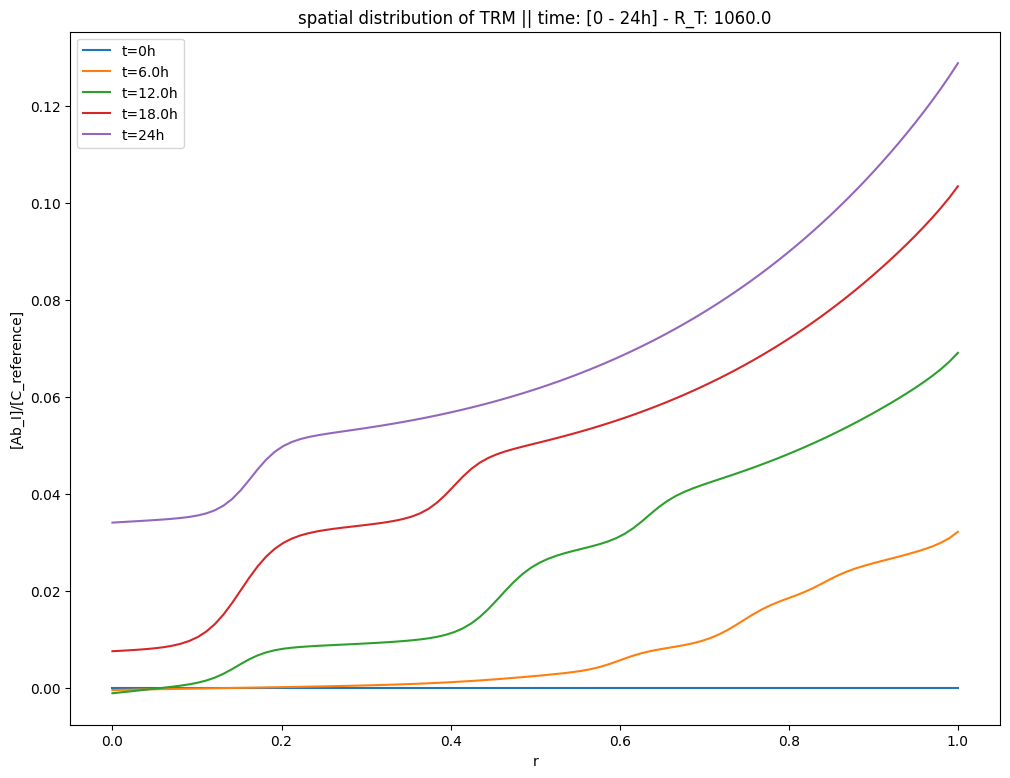

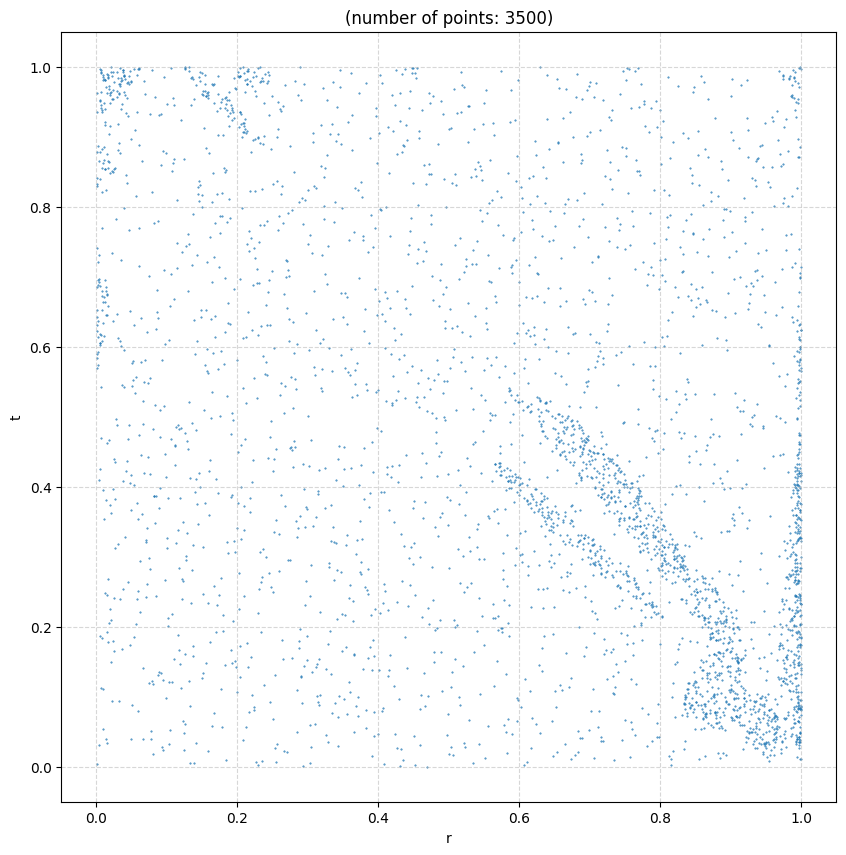

[RAR-G] round  3 | points= 3500 | max_res=6.631e+01 | mean_res=9.224e+00
Adam Training started...
- Epochs: 10000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 1.7998e+00 | 1.9435e-01 | 1.7927e-01 | 1.7579e-04 | 4.9826e-03 | 1.4210e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 1.9684e+00 | 1.7295e-01 | 3.4931e-01 | 1.9728e-04 | 4.6289e-03 | 1.4413e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 1.3077e+01 | 1.1547e+00 | 1.0432e+01 | 1.7819e-04 | 4.4617e-03 | 1.4855e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 1.6768e+00 | 1.1998e-01 | 1.5883e-01 | 1.8782e-04 | 4.7342e-0

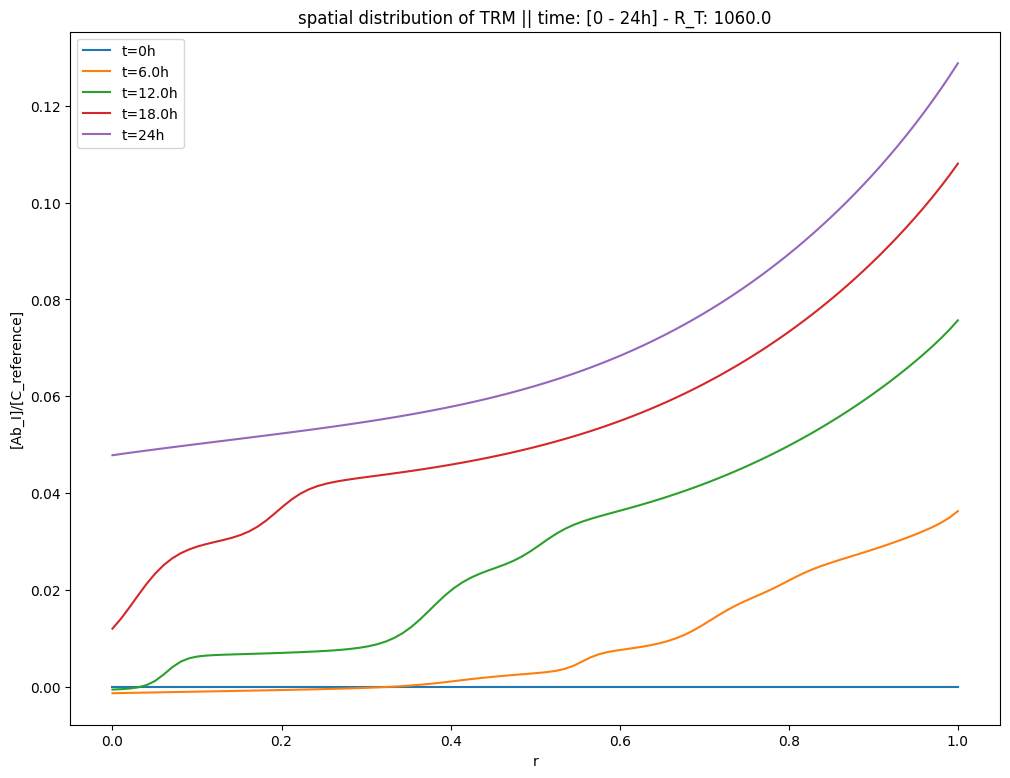

[{'round': 1,
  'n_points': 2500,
  'max_score': 179.4383087158203,
  'mean_score': 14.86580753326416},
 {'round': 2,
  'n_points': 3000,
  'max_score': 91.09228515625,
  'mean_score': 10.916605949401855},
 {'round': 3,
  'n_points': 3500,
  'max_score': 66.311279296875,
  'mean_score': 9.224464416503906}]

In [ ]:
import torch
from pathlib import Path

from trastuzumab import pinns, residuals, neural_nets, datasets, sampling



state = torch.load(Path.cwd().parent/'models/icc_pinn.pt')
state['state_dict']

net = neural_nets.FCNN(3, 64)
net.load_state_dict(state['state_dict'])

pinn = pinns.Pinn(net=net, n_col=2000, n_initial=200, n_center=200, n_surface=200, u_bounds=[1, 1], device='cpu', layers=3, neurons=64)
optimizer = torch.optim.Adam(pinn.net.parameters(), 0.001)

log = sampling.rar_g(pinn, optimizer=optimizer, n_rounds=10, rnd_epochs=2000, point_budget=10000, warmup_epochs=0)
log

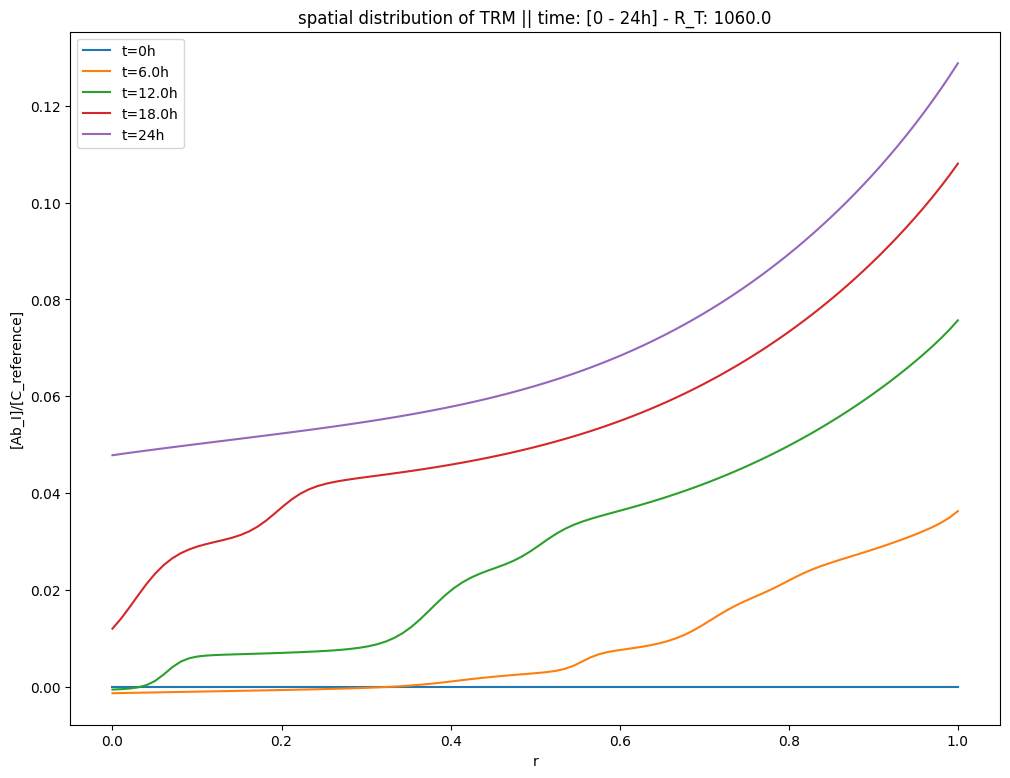

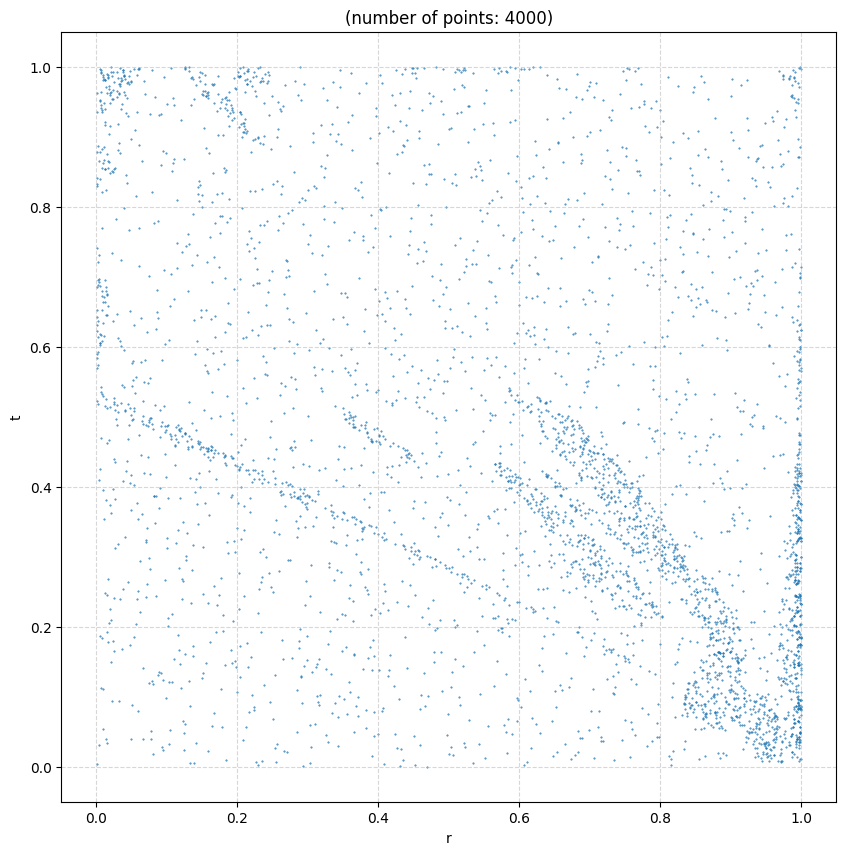

[RAR-G] round  1 | points= 4000 | max_res=5.778e+01 | mean_res=7.959e+00
Adam Training started...
- Epochs: 2000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 1.3023e+00 | 8.8962e-02 | 2.1142e-01 | 1.5311e-04 | 5.1294e-03 | 9.9660e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 1.2216e+00 | 8.0850e-02 | 1.4159e-01 | 1.3318e-04 | 4.8139e-03 | 9.9420e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 2.1971e+00 | 1.9525e-01 | 9.9521e-01 | 1.2771e-04 | 4.7438e-03 | 1.0018e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 1.3030e+00 | 1.0331e-01 | 2.1225e-01 | 1.2665e-04 | 4.7092e-03

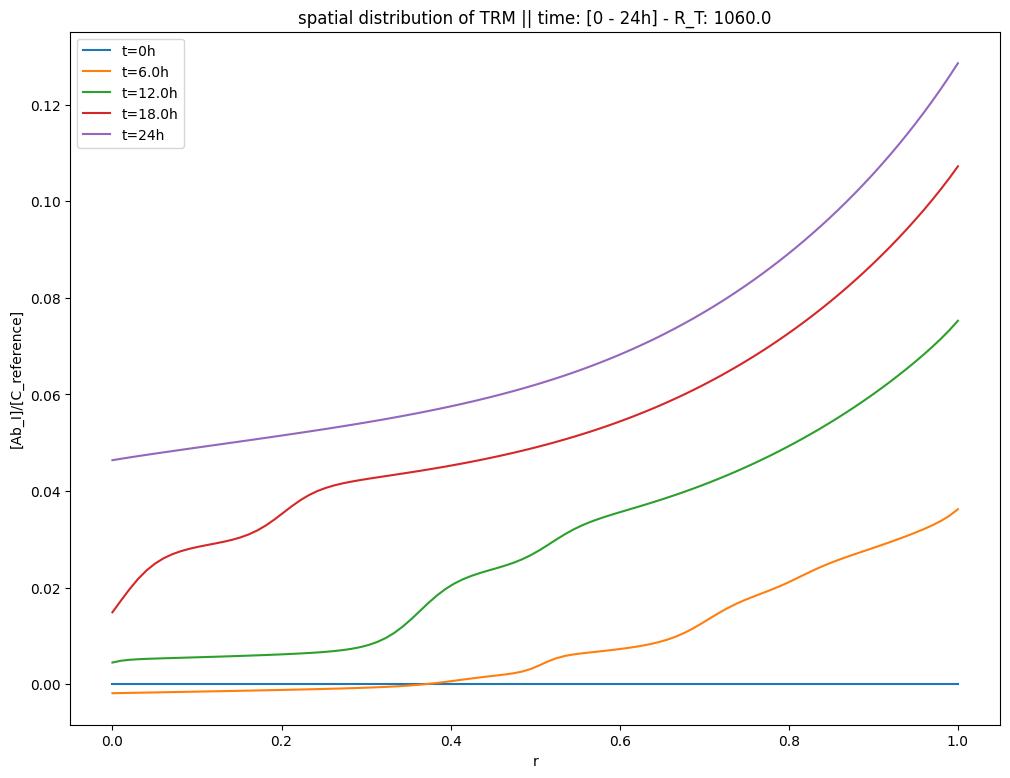

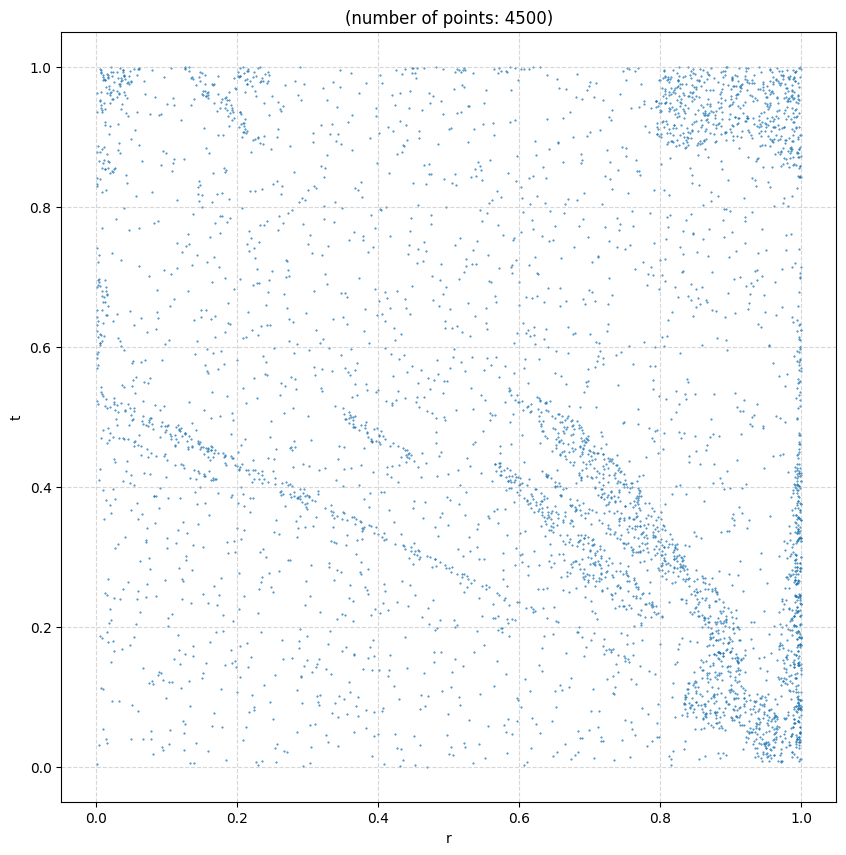

[RAR-G] round  2 | points= 4500 | max_res=8.999e+01 | mean_res=2.337e+01
Adam Training started...
- Epochs: 2000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 2.1659e+00 | 4.1065e-01 | 7.9698e-01 | 1.3606e-04 | 4.6793e-03 | 9.5343e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 1.1845e+00 | 7.0396e-02 | 1.5185e-01 | 2.0758e-04 | 3.6891e-03 | 9.5833e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 1.1577e+00 | 6.5904e-02 | 1.3716e-01 | 1.6564e-04 | 3.6509e-03 | 9.5087e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 1.1507e+00 | 6.5465e-02 | 1.3296e-01 | 1.5470e-04 | 3.6428e-03

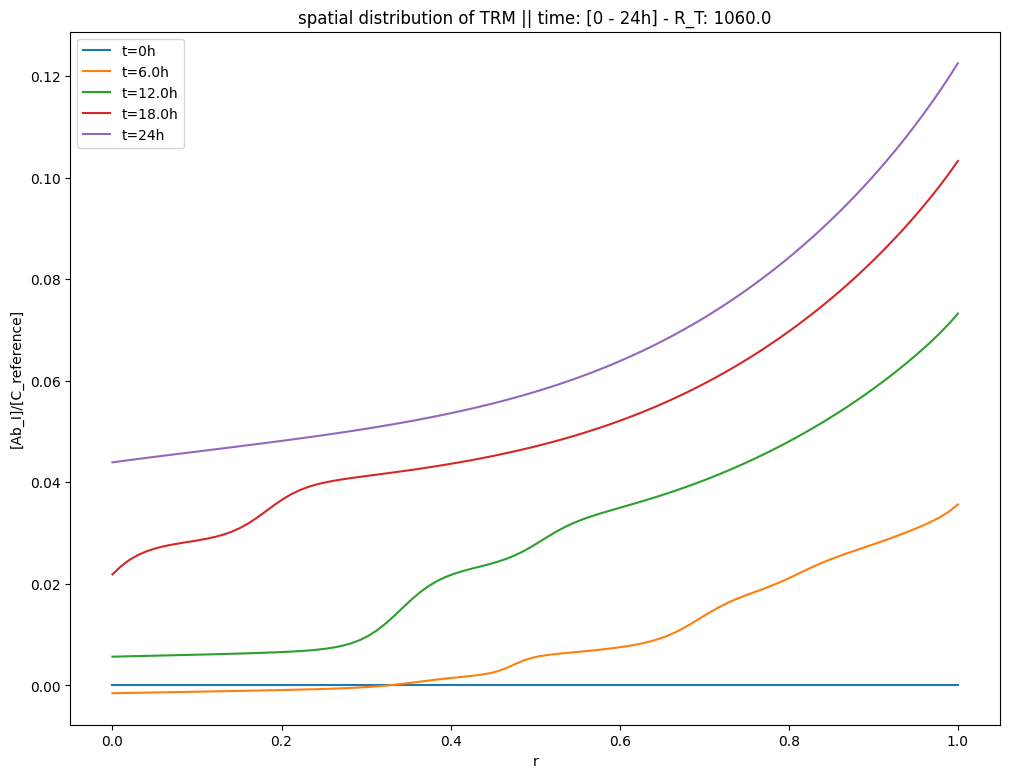

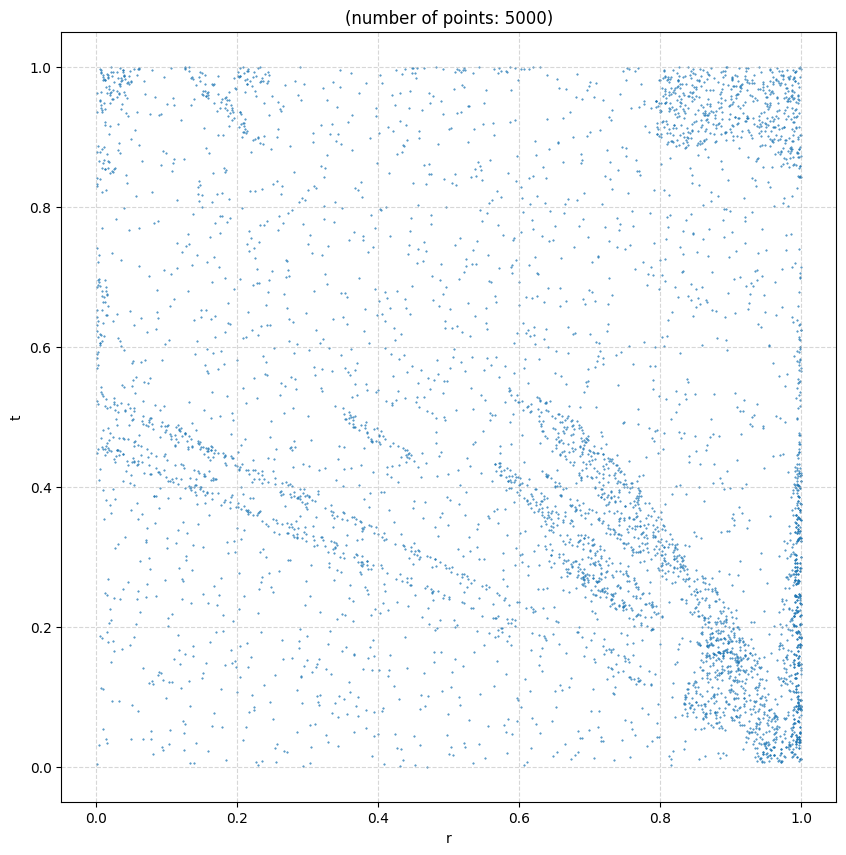

[RAR-G] round  3 | points= 5000 | max_res=5.656e+01 | mean_res=7.389e+00
Adam Training started...
- Epochs: 2000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 1.1907e+00 | 8.1128e-02 | 1.7433e-01 | 1.2648e-04 | 3.8519e-03 | 9.3130e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 3.5449e+00 | 4.4266e-01 | 2.1631e+00 | 1.2836e-04 | 3.6960e-03 | 9.3535e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 1.1507e+00 | 7.6805e-02 | 1.4093e-01 | 1.2093e-04 | 3.7360e-03 | 9.2907e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 1.1478e+00 | 7.6835e-02 | 1.4095e-01 | 1.1790e-04 | 3.7403e-03

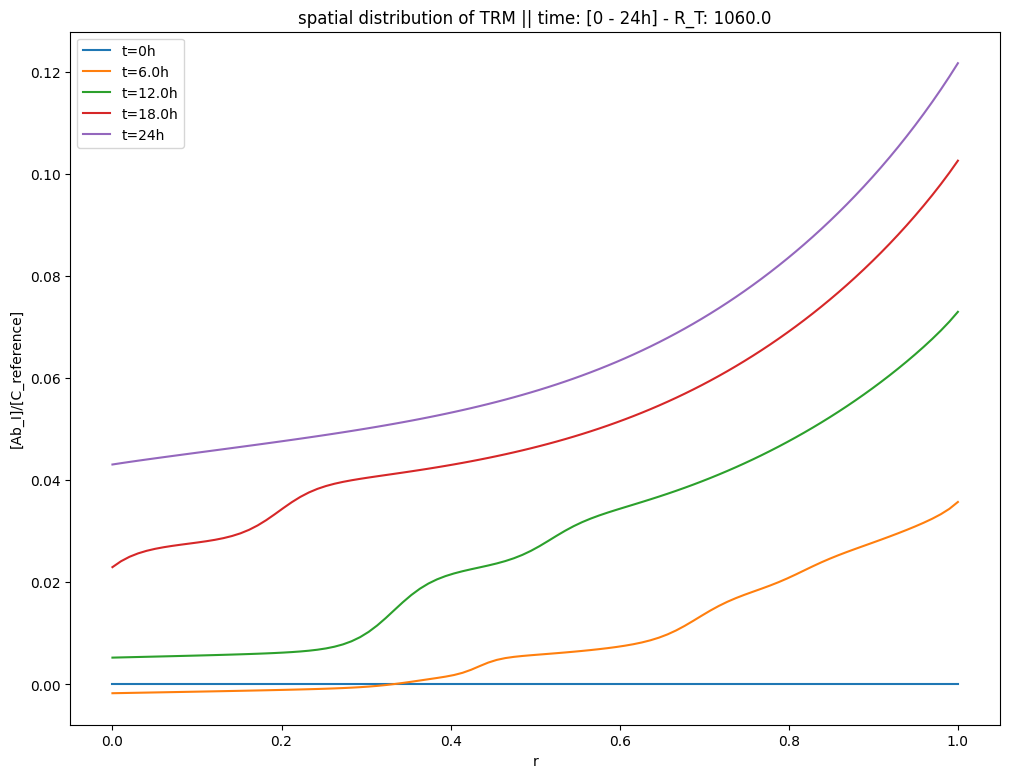

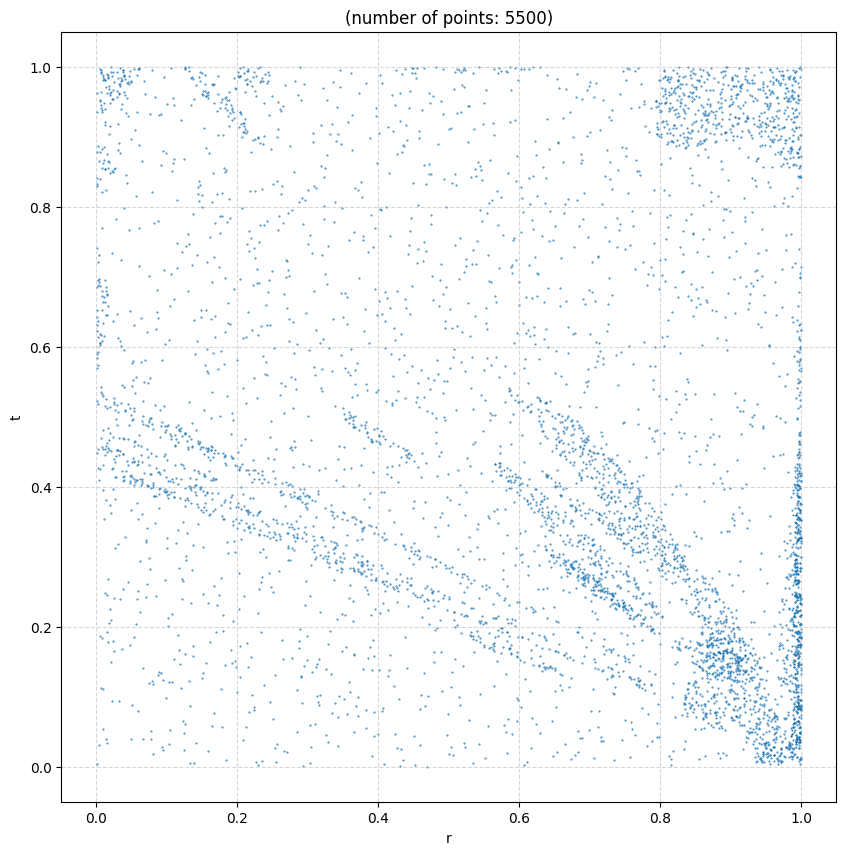

[RAR-G] round  4 | points= 5500 | max_res=5.857e+01 | mean_res=7.170e+00
Adam Training started...
- Epochs: 2000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 1.1613e+00 | 8.6134e-02 | 1.6778e-01 | 9.6334e-05 | 3.6683e-03 | 9.0367e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 1.3132e+00 | 8.2096e-02 | 3.2289e-01 | 9.5057e-05 | 3.5887e-03 | 9.0449e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 1.1328e+00 | 8.2520e-02 | 1.4756e-01 | 9.2094e-05 | 3.5016e-03 | 8.9913e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 1.1243e+00 | 8.1609e-02 | 1.4385e-01 | 8.9236e-05 | 3.4881e-03

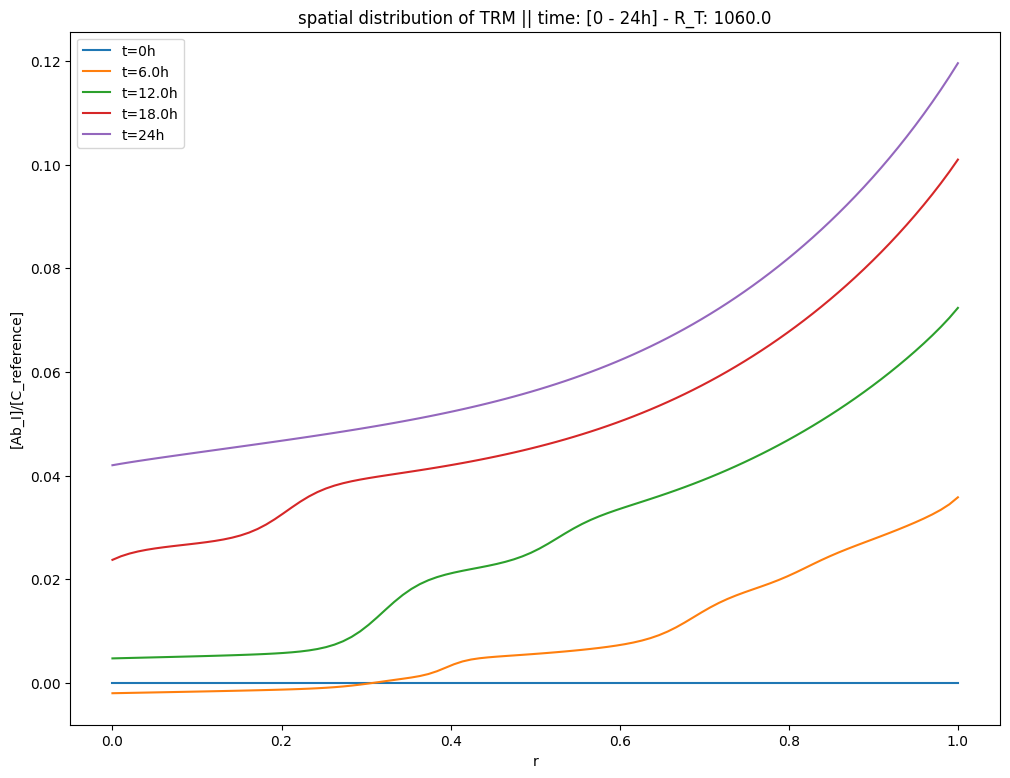

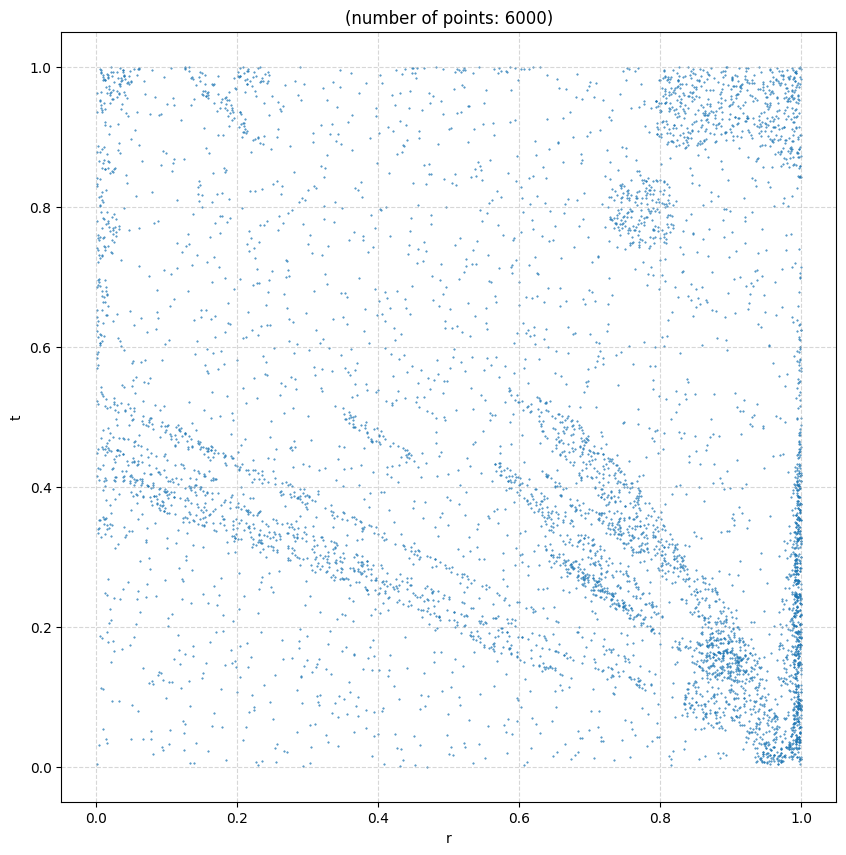

[RAR-G] round  5 | points= 6000 | max_res=5.898e+01 | mean_res=8.267e+00
Adam Training started...
- Epochs: 2000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 1.1741e+00 | 9.8187e-02 | 2.0180e-01 | 8.6598e-05 | 3.4326e-03 | 8.7063e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 1.1276e+00 | 8.9407e-02 | 1.6667e-01 | 8.6529e-05 | 3.3664e-03 | 8.6805e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 1.6781e+00 | 2.3837e-01 | 5.4787e-01 | 1.0028e-04 | 3.2578e-03 | 8.8849e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 1.1721e+00 | 8.2347e-02 | 2.2056e-01 | 8.3790e-05 | 3.2506e-03

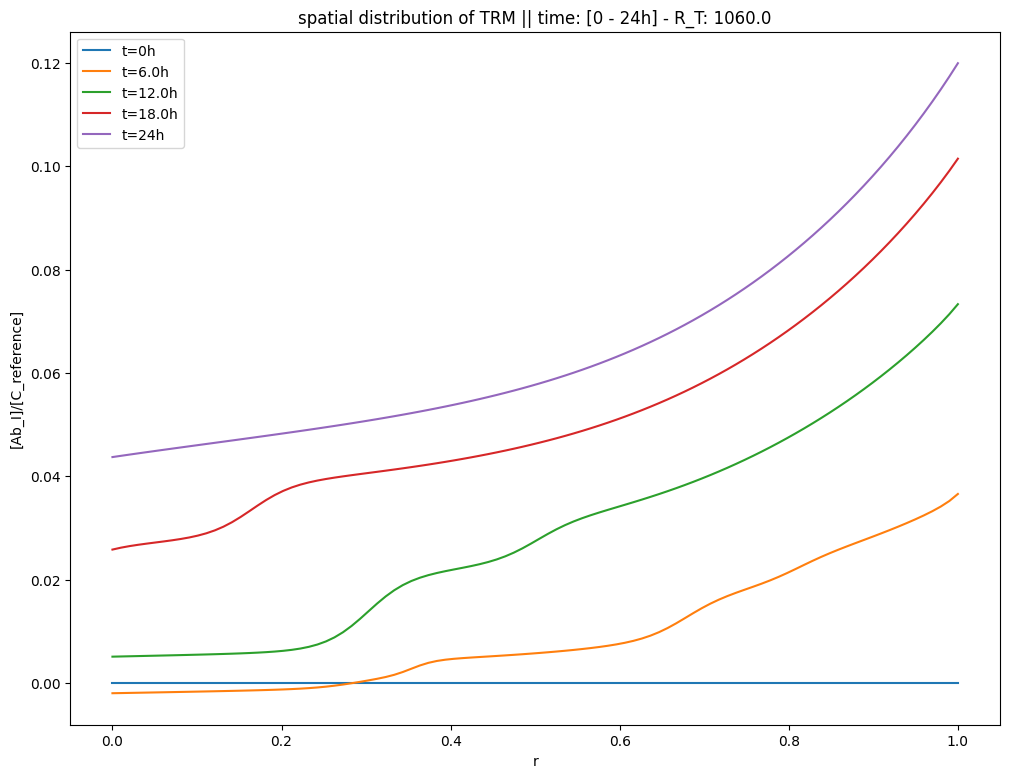

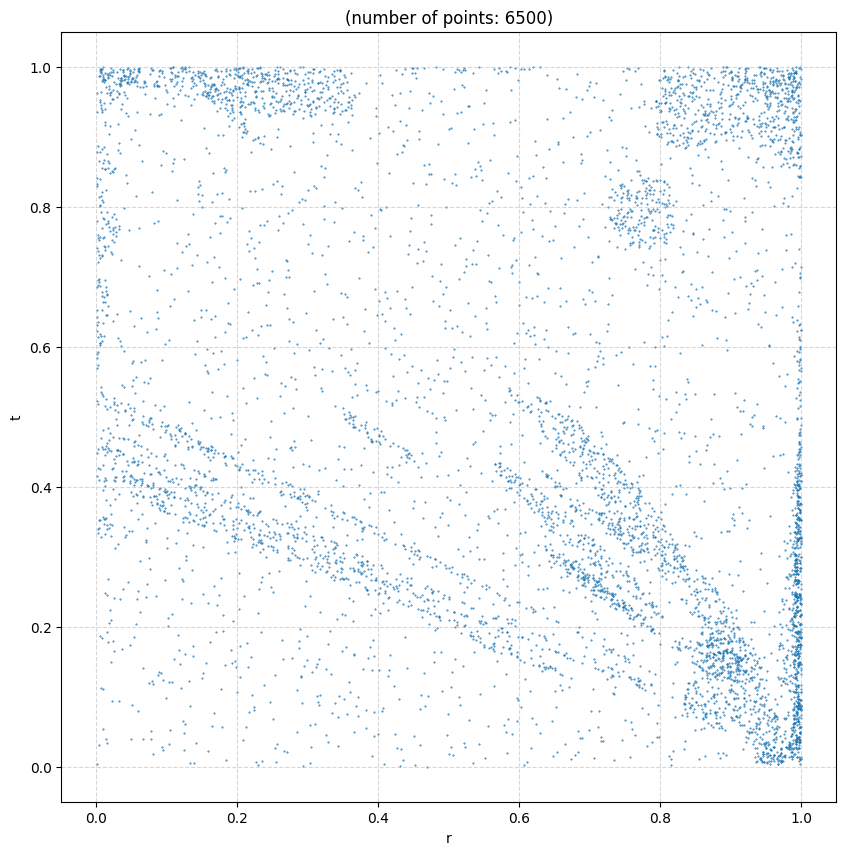

[RAR-G] round  6 | points= 6500 | max_res=1.642e+02 | mean_res=7.289e+01
Adam Training started...
- Epochs: 2000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 8.7496e+00 | 1.5921e+00 | 6.2994e+00 | 7.7554e-05 | 3.1009e-03 | 8.5493e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 1.0912e+00 | 8.6832e-02 | 1.5544e-01 | 3.3441e-04 | 2.6040e-03 | 8.4597e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 1.0665e+00 | 7.6542e-02 | 1.4606e-01 | 1.9503e-04 | 2.5917e-03 | 8.4116e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 1.0573e+00 | 7.4441e-02 | 1.4090e-01 | 1.3830e-04 | 2.5858e-03

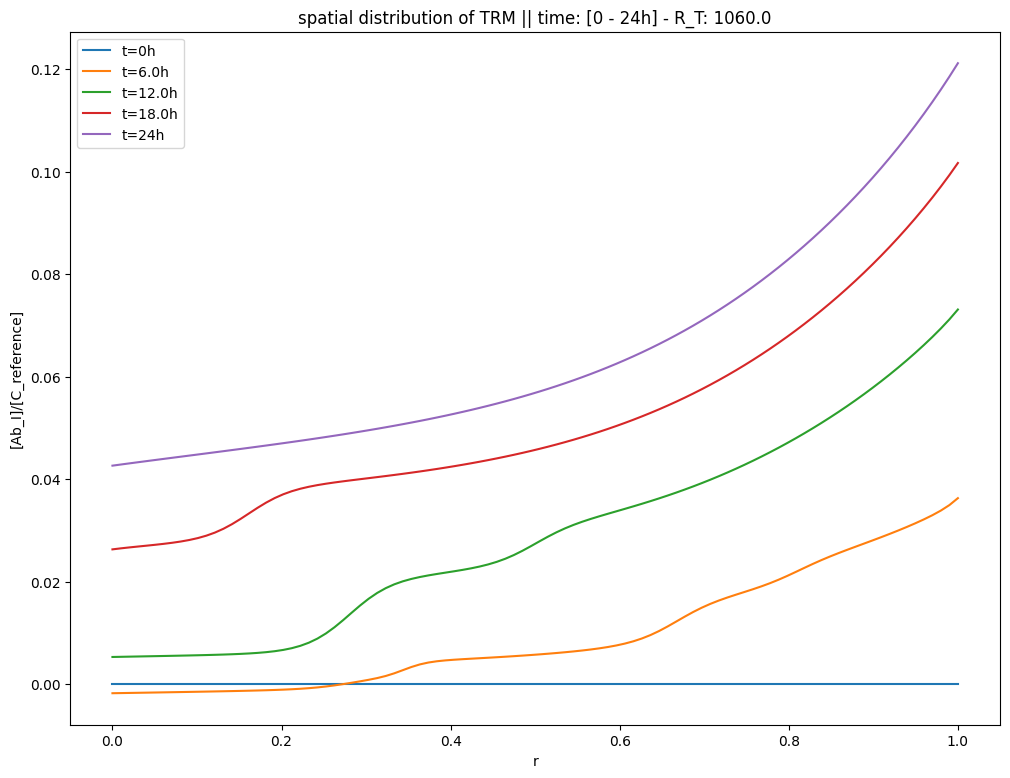

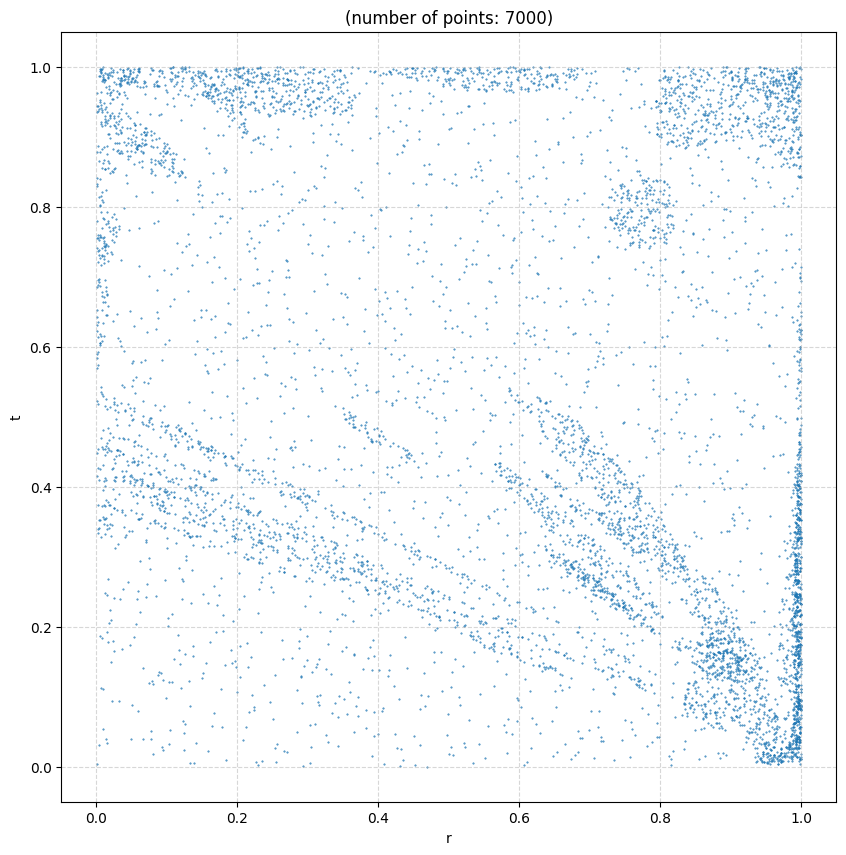

[RAR-G] round  7 | points= 7000 | max_res=5.868e+01 | mean_res=1.179e+01
Adam Training started...
- Epochs: 2000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 1.1776e+00 | 8.2689e-02 | 2.6384e-01 | 9.7532e-05 | 2.8118e-03 | 8.2814e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 1.0573e+00 | 7.6437e-02 | 1.5227e-01 | 8.7860e-05 | 3.0623e-03 | 8.2545e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 1.0517e+00 | 7.5773e-02 | 1.4888e-01 | 7.7566e-05 | 3.0107e-03 | 8.2393e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 1.0470e+00 | 7.5542e-02 | 1.4592e-01 | 7.4985e-05 | 2.9609e-03

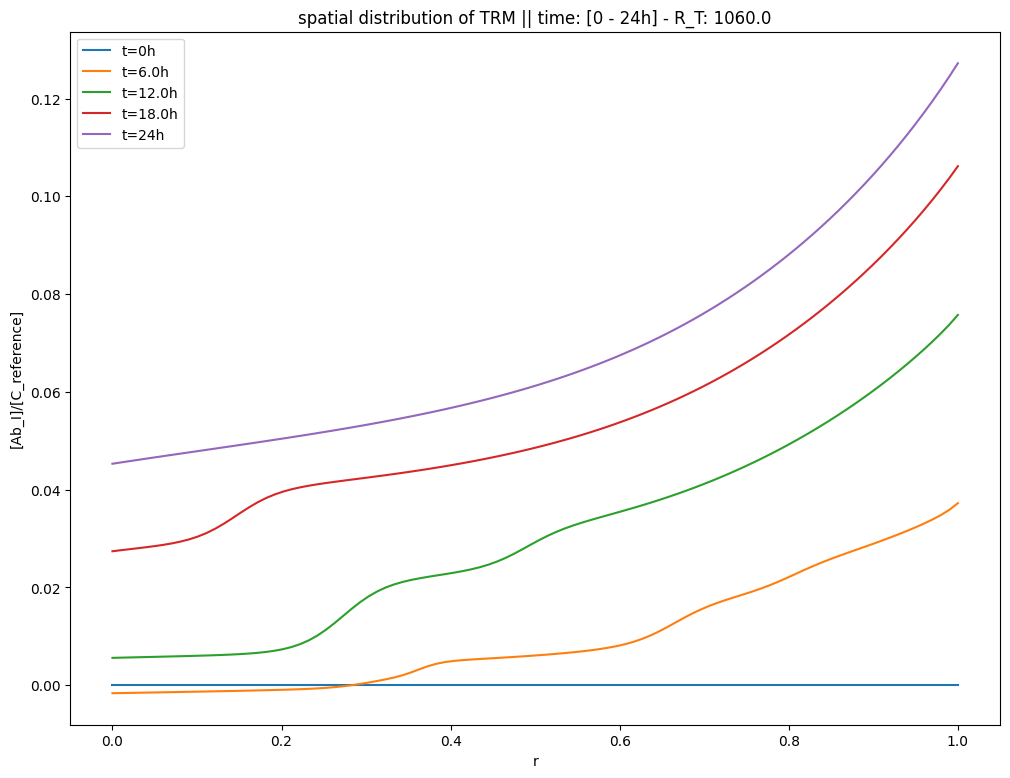

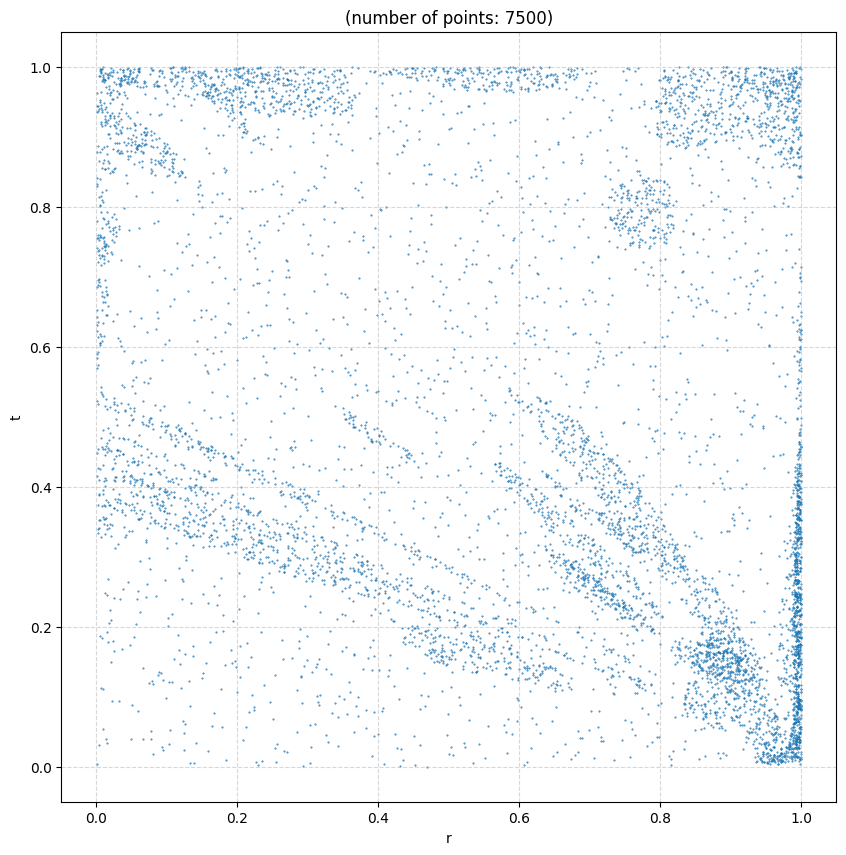

[RAR-G] round  8 | points= 7500 | max_res=6.305e+01 | mean_res=7.399e+00
Adam Training started...
- Epochs: 2000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 1.0569e+00 | 7.9734e-02 | 1.6597e-01 | 6.8363e-05 | 3.0186e-03 | 8.0815e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 1.0639e+00 | 8.5007e-02 | 1.6889e-01 | 6.8936e-05 | 2.9271e-03 | 8.0702e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 1.1757e+00 | 8.9952e-02 | 2.7237e-01 | 7.2469e-05 | 2.9166e-03 | 8.1038e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 1.0548e+00 | 8.0036e-02 | 1.6964e-01 | 6.5102e-05 | 2.9113e-03

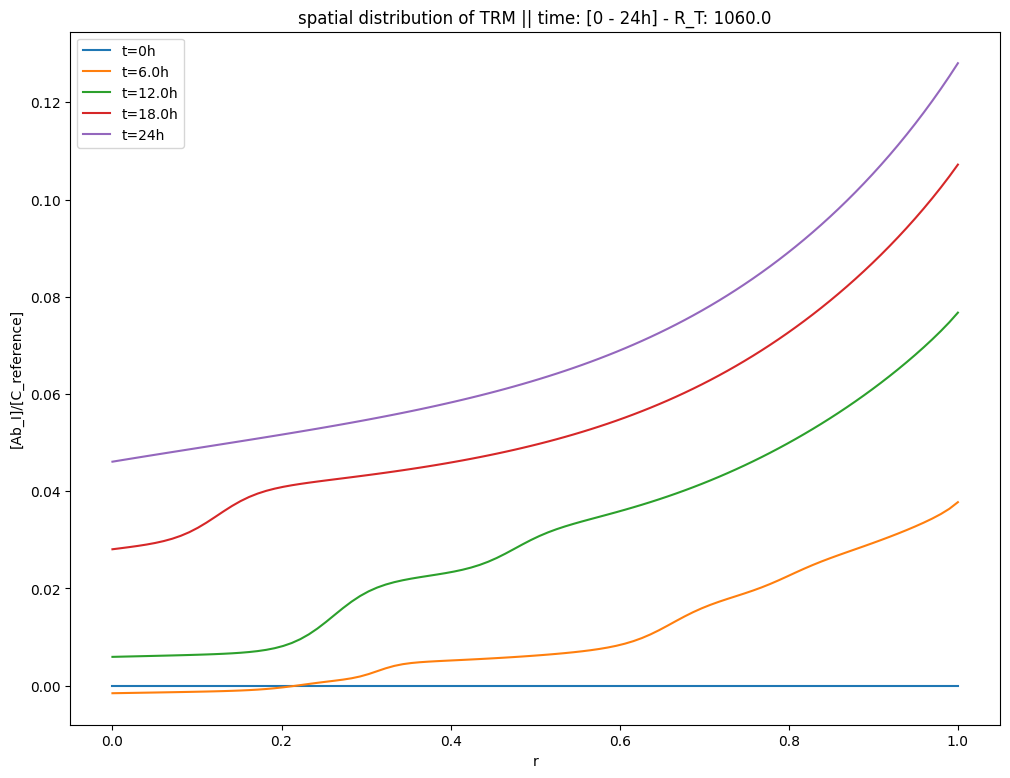

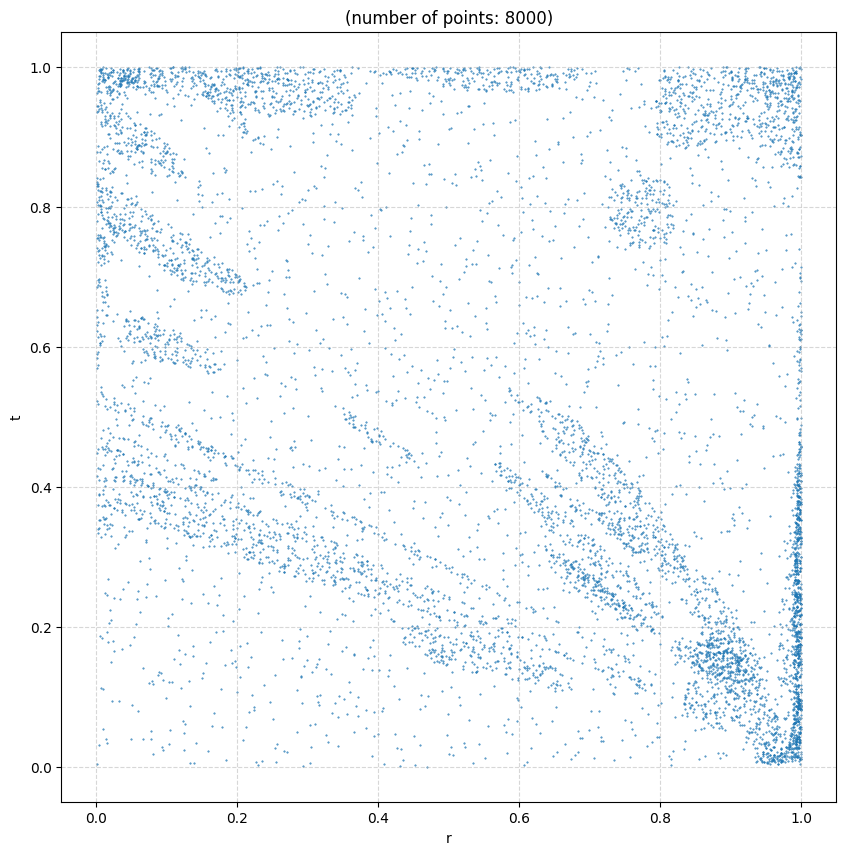

[RAR-G] round  9 | points= 8000 | max_res=6.118e+01 | mean_res=2.015e+01
Adam Training started...
- Epochs: 2000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 1.6596e+00 | 1.0965e-01 | 7.3315e-01 | 6.9202e-05 | 2.8491e-03 | 8.1386e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 1.0252e+00 | 7.2897e-02 | 1.6068e-01 | 1.0575e-04 | 2.2264e-03 | 7.8931e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 1.0102e+00 | 7.2136e-02 | 1.4716e-01 | 7.7933e-05 | 2.2190e-03 | 7.8864e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 1.0047e+00 | 7.2054e-02 | 1.4284e-01 | 7.0217e-05 | 2.2292e-03

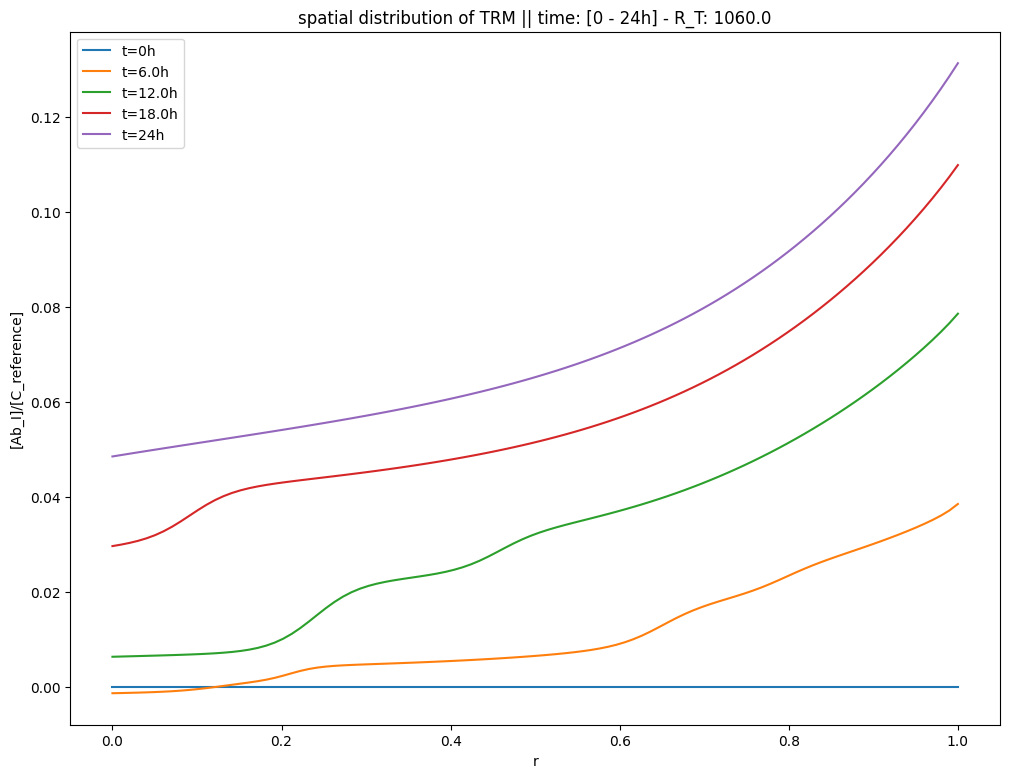

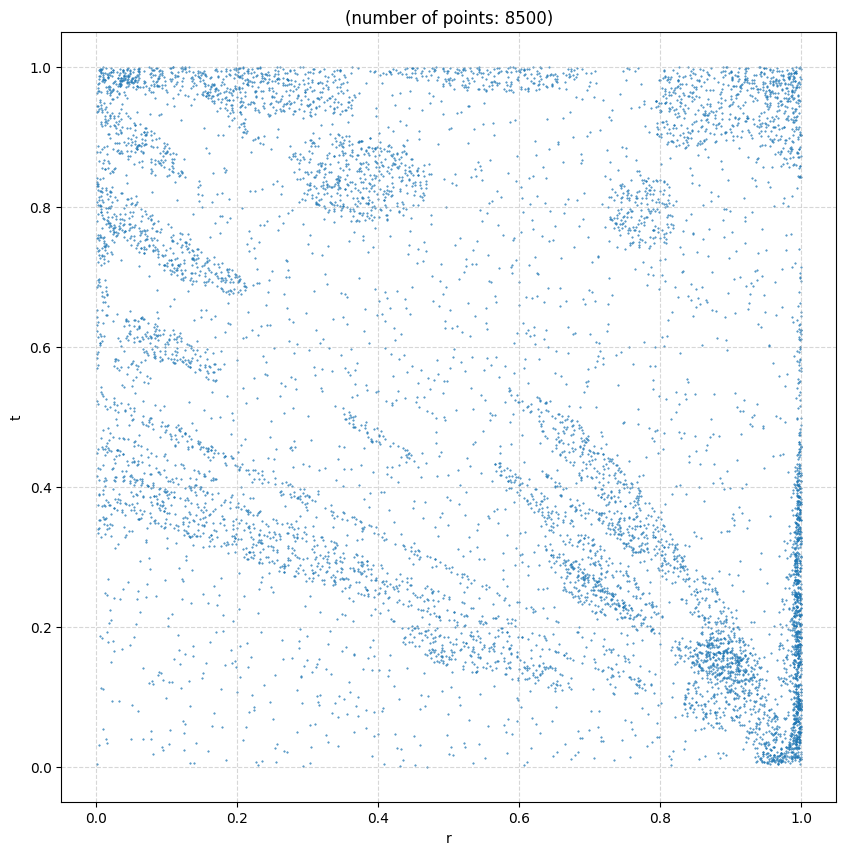

[RAR-G] round 10 | points= 8500 | max_res=6.561e+01 | mean_res=1.268e+01
Adam Training started...
- Epochs: 2000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 1.1698e+00 | 1.0750e-01 | 2.7958e-01 | 7.4591e-05 | 2.6400e-03 | 7.8003e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 1.1293e+00 | 9.3260e-02 | 2.5792e-01 | 5.7224e-05 | 2.6583e-03 | 7.7540e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 1.0148e+00 | 7.8574e-02 | 1.6013e-01 | 5.7074e-05 | 2.6801e-03 | 7.7335e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 1.0840e+00 | 8.7677e-02 | 2.1962e-01 | 5.7000e-05 | 2.6852e-03

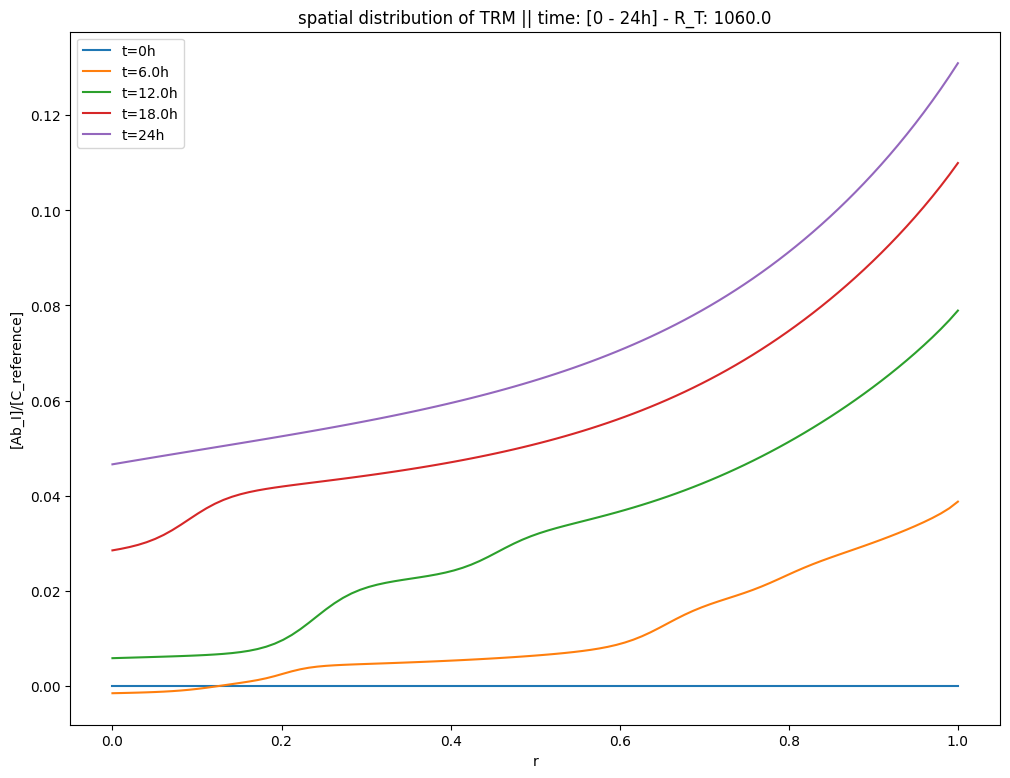

[{'round': 1,
  'n_points': 4000,
  'max_score': 57.783939361572266,
  'mean_score': 7.9587202072143555},
 {'round': 2,
  'n_points': 4500,
  'max_score': 89.99349975585938,
  'mean_score': 23.372068405151367},
 {'round': 3,
  'n_points': 5000,
  'max_score': 56.55525588989258,
  'mean_score': 7.389497756958008},
 {'round': 4,
  'n_points': 5500,
  'max_score': 58.56504440307617,
  'mean_score': 7.169676780700684},
 {'round': 5,
  'n_points': 6000,
  'max_score': 58.97614669799805,
  'mean_score': 8.267423629760742},
 {'round': 6,
  'n_points': 6500,
  'max_score': 164.19403076171875,
  'mean_score': 72.89258575439453},
 {'round': 7,
  'n_points': 7000,
  'max_score': 58.67692565917969,
  'mean_score': 11.790657997131348},
 {'round': 8,
  'n_points': 7500,
  'max_score': 63.051265716552734,
  'mean_score': 7.398717880249023},
 {'round': 9,
  'n_points': 8000,
  'max_score': 61.177608489990234,
  'mean_score': 20.150239944458008},
 {'round': 10,
  'n_points': 8500,
  'max_score': 65.613

In [2]:
log = sampling.rar_g(pinn, optimizer=optimizer, n_rounds=10, rnd_epochs=2000, point_budget=10000, warmup_epochs=0)
log

neural network weights initialized succesfully
-----------------------------------------------------------------------------------------------------------------------------------------
   epoch    |    total    |    pde0     |    pde1     |    pde2     |     ic0     |     ic1     |     ic2     |   center    |   surface  
-----------------------------------------------------------------------------------------------------------------------------------------
     0      |  1.499e+03  |  2.542e+02  |  1.245e+03  |  3.948e-04  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00 


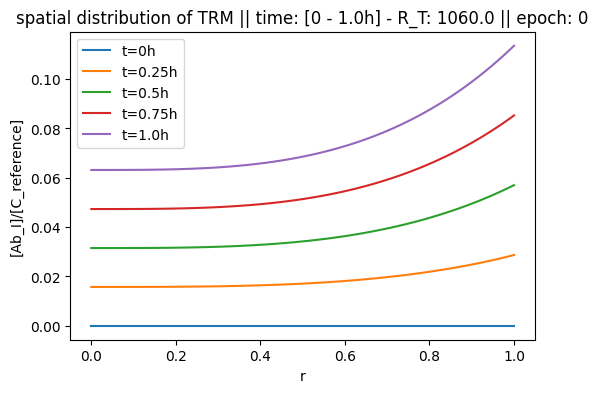

    200     |  1.744e-02  |  5.996e-03  |  1.145e-02  |  1.756e-07  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00 
    400     |  1.739e-02  |  5.979e-03  |  1.141e-02  |  7.714e-08  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00 
    600     |  1.730e-02  |  5.927e-03  |  1.137e-02  |  5.189e-08  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00 
    800     |  1.722e-02  |  5.908e-03  |  1.131e-02  |  4.288e-08  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00 
   1000     |  1.712e-02  |  5.855e-03  |  1.127e-02  |  3.530e-08  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00 


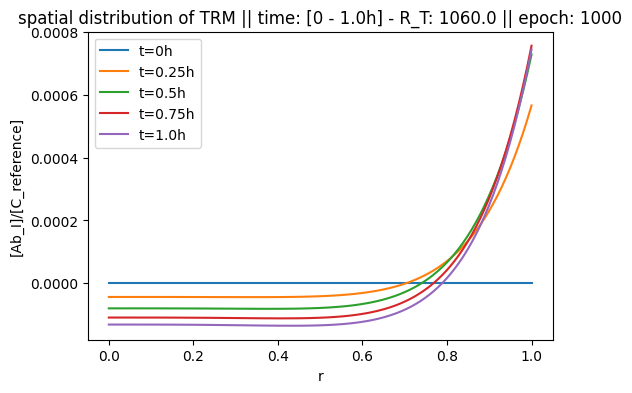

   1200     |  1.704e-02  |  5.872e-03  |  1.116e-02  |  2.779e-08  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00 
   1400     |  1.693e-02  |  5.841e-03  |  1.109e-02  |  2.064e-08  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00 
   1600     |  1.682e-02  |  5.734e-03  |  1.109e-02  |  1.420e-08  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00 
   1800     |  1.672e-02  |  5.735e-03  |  1.099e-02  |  8.831e-09  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00 


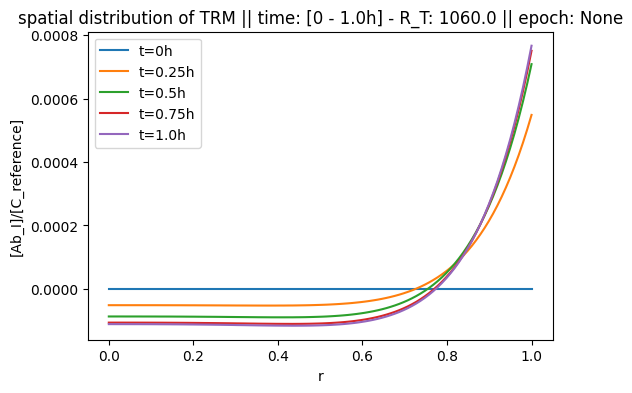

In [1]:
# \\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\
_T = 1.0; _L = 1060/1060
COLLOC = 2000; INITIAL_POINTS = 200; CENTER_POINTS = 200; SURFACE_POINTS = 200
HARD_COND = ('ic', 'neumann', 'robin')
EPOCHS = 2000; LR = 0.001
# \\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\

import torch
from trastuzumab import pinns, neural_nets, trainer as tr, constants as cst, constrained_net as cn

def IC_A(r, epsilon=0.14, n=70):
    return epsilon * r**n

def IC_B(r: torch.Tensor) -> torch.Tensor:
    return r * 0.0

fcnn = neural_nets.FCNN(6, 128, initialization=True, seed=42)
c_net = cn.ConstrainedNet(inner_net=fcnn, beta=pinns.BasePinn.BETA, c_sol_star=cst.C_SOL_STAR, eps=0.01, enforce=HARD_COND)
pinn = pinns.ForwardPinn(n_col=COLLOC, n_initial=INITIAL_POINTS, n_center=CENTER_POINTS, n_surface=SURFACE_POINTS, u_bounds=(1.0, _T / 24), initial_fn=IC_A, net=c_net, hard_conditions=HARD_COND)

adam = torch.optim.Adam(pinn.net.parameters(), lr=LR)
lbfgs = torch.optim.LBFGS(pinn.net.parameters(), lr=0.001, max_iter=20, history_size=100, line_search_fn='strong_wolfe')

loss_weights = {'pde0': 1e-4, 'pde1': 1e-4, 'pde2':1.0, 'ic0': 1.0, 'ic1': 1.0, 'ic2': 1.0, 'center': 1.0, 'surface': 1e6}
trainer = tr.Trainer(pinn, loss_weights, pde_normalized=False)
trainer.train(adam, epochs=EPOCHS, L=_L, log_every=200, profile_every=1000)
pinn.check_concentration_profile(L=_L)

In [6]:
from trastuzumab import pinns

def train_in_another_time_frame(pinn: pinns.BasePinn, new_t, new_pde: int = 200, new_bc: int = 20, L=1.0, epochs_per_window: int = 2000):
    t_old = pinn.lower_bounds[1]
    pinn.resample_datasets(new_pde, new_bc, new_bc, new_bc, lower_bounds=(0.0, t_old), upper_bounds=(1.0, new_t/24))
    trainer.train(adam, epochs=epochs_per_window, L=L)

def greedy_training(pinn, start, finish, L=1.0 , epochs: int = 2000):
    for new_t in range(start, finish+1):
        train_in_another_time_frame(pinn, new_t, new_pde=200, new_bc=20, L=1.0, epochs_per_window=2000)

In [9]:
greedy_training(pinn, 2, 4, L=1.0)

points resampled...
-new total: 3640
-upper_bounds: (1.0, 0.08333333333333333)
-----------------------------------------------------------------------------------------------------------------------------------------
   epoch    |    total    |    pde0     |    pde1     |    pde2     |     ic0     |     ic1     |     ic2     |   center    |   surface  
-----------------------------------------------------------------------------------------------------------------------------------------
     0      |  1.770e-02  |  5.725e-03  |  1.197e-02  |  9.423e-09  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00  |  0.000e+00 


ZeroDivisionError: integer division or modulo by zero

In [ ]:
from trastuzumab import fdm, evaluation
import numpy as np

fdm_x, fdm_sol = fdm.run_fdm(m=100, phase_name='uptake', y0=np.zeros(3*(100+1)), t_final=1.0)
ev = evaluation.Evaluator(fdm_x, fdm_sol.sol, n_t=101)
ev.compare()

[uptake] solver: The solver successfully reached the end of the integration interval.
1.010938840295699
{'c0': 1.0001512977083016, 'c1': 1.0681309878568455, 'c2': 1.0060743105427454}


In [22]:
def time_marching_pinn(pinn: pinns.BasePinn, start: int = 0, finish: int = 24, epochs_perround: int = 10000, L=1.0):
    for i in range(start, finish + 1):
        new_colloc = i * 100
        new = i * 10
        pinn.resample_datasets(2000 + new_colloc, 200+new, 200+new, 200+new, upper_bounds=(1.0, i/24))
        trainer.train(optimizer, epochs_perround, L=L)
        pinn.check_concentration_profile(L=L)

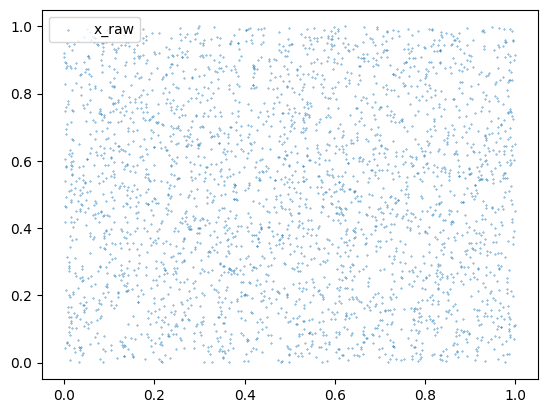

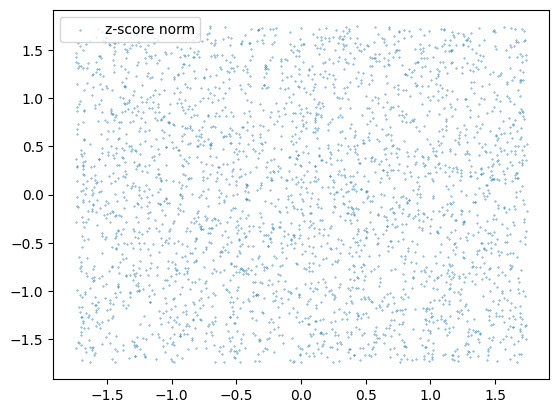

0.9999999999999999 1.9303077654816054e-16


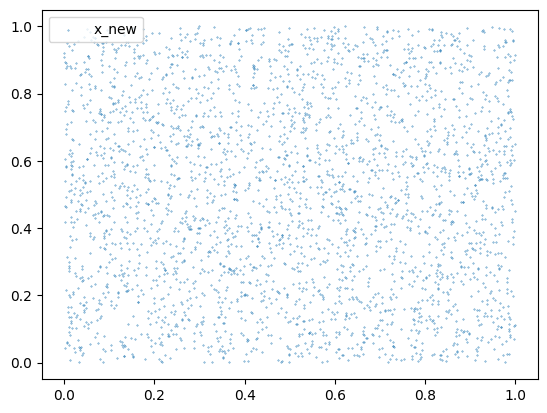

In [67]:
# data normalization, inner-layer normalization, output-normalization.

import numpy as np
import matplotlib.pyplot as plt

def denormalize(x_norm: np.ndarray, std_x, mean_x):
    return x_norm * std_x + mean_x

def scatter(x, size=0.1, label=None):
    plt.scatter(x[:, 0:1], x[:, 1:2], s=size, label=label)
    plt.legend()
    plt.show()


x = np.random.rand(3000, 2)
mean_x = np.mean(x)
std_x = np.std(x)

scatter(x, label='x_raw')

x_norm = ((x - mean_x) /  std_x)
scatter(x_norm, label='z-score norm')
print(x_norm.std(), x_norm.mean())

x_new = denormalize(x_norm, std_x, mean_x)
scatter(x_new, label='x_new')




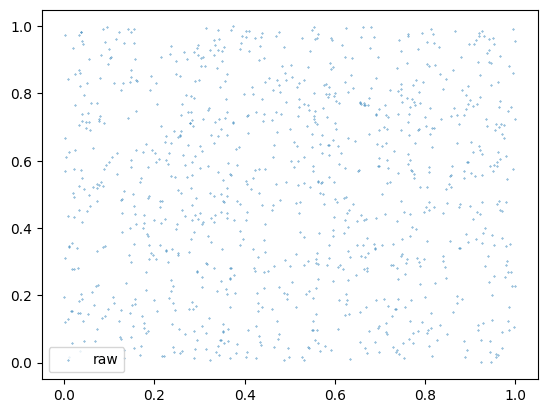

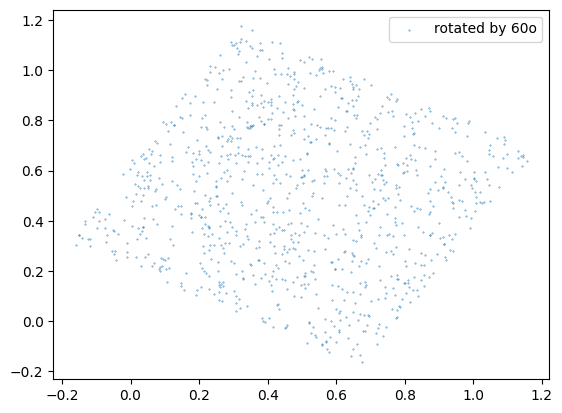

In [64]:
import numpy as np

x = np.random.rand(1000, 2)
scatter(x, label='raw')


rotation_matrix = lambda theta: np.array([[np.cos(theta), -np.sin(theta)],
                                          [np.sin(theta), np.cos(theta)]])


degrees = 60
R = rotation_matrix(np.radians(degrees))
center = np.array([0.5, 0.5])

rotated = (R @ (x - center).T).T + center
scatter(rotated, label=f'rotated by {degrees}o')

In [7]:
from trastuzumab import neural_nets
import torch.nn as nn

net = neural_nets.FCNN(n_layers=3, n_neurons=4, initialization=True)


for layer in net.layers:
    print(layer.weight)
    print(layer.bias)



neural network weights initialized succesfully
Parameter containing:
tensor([[ 0.1789,  0.5078],
        [-0.6095, -0.9899],
        [-0.3864, -0.7670],
        [ 0.8205,  0.2880]], requires_grad=True)
Parameter containing:
tensor([0., 0., 0., 0.], requires_grad=True)
Parameter containing:
tensor([[ 0.3587,  0.2739, -0.0151,  0.6778],
        [-0.6153,  0.0545, -0.5911,  0.2670],
        [-0.2982,  0.2654, -0.1804,  0.7183],
        [-0.5133, -0.5165, -0.5165,  0.7789]], requires_grad=True)
Parameter containing:
tensor([0., 0., 0., 0.], requires_grad=True)
Parameter containing:
tensor([[ 0.3085,  0.8909, -0.7641, -0.9183],
        [-0.7243, -0.6228,  0.3750,  0.3315],
        [ 0.7693, -0.4781, -0.6311,  0.4912]], requires_grad=True)
Parameter containing:
tensor([0., 0., 0.], requires_grad=True)
